# Screening von **L0**-Reweighting-Potenzialen — DFT sparen während der MD

**Kann man aus wenigen DFT-Einzelpunkten früh entscheiden, ob das
thermodynamische Reweighting eines L0-Modells gutartige $N_\text{eff}$ liefern
wird — und so den Großteil der DFT-Kampagne sparen?**

Forschungspraktikum, Gruppe Kresse (Univ. Wien) · Betreuung T. Hilpert
Zielpaper: Hilpert & Kresse, *J. Chem. Phys.* **164**, 194504 (2026)

---

**Warum L0.** Die Methodik dieses Notebooks zielt auf die **L0-Modelle** — genau den
Fall, in dem die **MD billiger ist als DFT**. Dann dominieren die DFT-Einzelpunkte die
Kosten, und ein frühes Abbrechen einer aussichtslosen Reweighting-Rechnung spart real
Rechenzeit. Für die großen L2-Modelle dominiert die MD; dort greift das sequenzielle
DFT-Sparen kaum, und L2c dient hier nur als **gutartiger Kontrast** (klares PASS, exakte
Kumulantenformel).

Das Notebook dokumentiert die Methode systematisch: Formalismus mit allen Annahmen,
numerische Belege auf den realen L0-Daten, und Verifikation des Codes gegen analytische
Grenzfälle. Es fasst die Analysen `12_screening` und `13_sequential_screening` in einer
nachvollziehbaren Erzählung zusammen — angewendet auf L0.

> **Aufbau-Status:** Gerüst. Die Abschnitte sind angelegt und werden Schritt für
> Schritt gefüllt.

## Inhaltsverzeichnis

*Setup: [Bibliothek, Pfade, Daten](#setup)*

1. [Fragestellung und Überblick](#1)
2. [Der Formalismus: $c$ und die Kumulantenentwicklung](#2)
3. [Die zwei Annahmen (A1–A2)](#3)
4. [Die Verteilung von $\Delta E$](#4)
5. [Die drei Diagnosegrößen: $c$, $\hat k$, $N_\text{eff}$](#5)
6. [Konvergenz der Momente](#6)
7. [Die Entscheidungsschranke (Gauß vs. schiefe-korrigiert)](#7)
8. [Der sequenzielle Workflow](#8)
9. [Existenz von $N_\text{eff}$ und die PASS/FAIL-Asymmetrie](#9)
10. [Verifikation: analytisch bekannte Wahrheit](#10)
11. [Grenzen: Abdeckung (A2) und Nicht-iid](#11)
12. [Zusammenfassung](#12)

<a id="setup"></a>
## Setup — Bibliothek, Pfade, Daten

Das Notebook liegt in `results/UQ_L0/`; die Projektbibliothek `uq_mace` liegt unter
`src/`. Die MACE-Energien sind in `cache/` vorberechnet (kein MACE-Neulauf nötig).

In [7]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Projekt-Root finden (zwei Ebenen ueber results/UQ_L0)
ROOT = Path.cwd()
while not (ROOT / "src" / "uq_mace").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
CACHE = ROOT / "cache"

from uq_mace.predictions import load_energies
from uq_mace.reweighting import (
    effective_sample_size, psis_khat, reweighting_weights, running_moments,
)

K_B = 8.617333262e-5          # eV/K
T   = 292.0                   # K  (Paper, Tabelle II)
beta = 1.0 / (K_B * T)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3})

# Fokus: die L0-Modelle (MD billiger als DFT -> DFT-Sparen lohnt sich).
# L2c/L2 nur als gutartiger Kontrast (PASS, exakte Kumulantenformel).
L0_MODELS = {
    "mace-L0-01":   "single_mace-L0-01_testbig.npz",
    "mace-L0-c-01": "single_mace-L0-c-01_testbig.npz",
}
REF_MODELS = {
    "ensemble_L2c": "mace_energies_ensemble_L2c_testbig.npz",   # Kontrast: gutartig
    "mace-L2-c-01": "single_mace-L2-c-01_testbig.npz",
}
MODELS = {**L0_MODELS, **REF_MODELS}
print(f"ROOT   = {ROOT}")
print(f"beta   = {beta:.3f} eV^-1  (T = {T:.0f} K)")
print(f"Caches: {sorted(p.name for p in CACHE.glob('*.npz'))}")

ROOT   = /Users/emil/Documents/GitHub/Kish_estimator
beta   = 39.742 eV^-1  (T = 292 K)
Caches: ['mace_energies_ensemble_L2c_testbig.npz', 'predictions_ensemble_L2c_testbig.npz', 'single_mace-L0-01_testbig.npz', 'single_mace-L0-01_testfull.npz', 'single_mace-L0-01_testfull_n5000.npz', 'single_mace-L0-c-01_testbig.npz', 'single_mace-L0-c-01_testfull.npz', 'single_mace-L0-c-01_testfull_n5000.npz', 'single_mace-L2-c-01_testbig.npz', 'single_mace-L2-c-01_testfull_n5000.npz', 'single_mace-L2-c-02_testbig.npz']


In [8]:
# Schneller Konsistenz-Check: laedt alles und zeigt die Kernzahlen je Modell
def summary(name):
    e_dft, e_mace = load_energies(CACHE / MODELS[name])
    dE = e_dft - e_mace
    w = reweighting_weights(e_dft, e_mace, beta)
    s = dE.std(ddof=1); u = dE - dE.mean()
    return dict(model=name, n=dE.size, c=beta*s,
                g1=float((u**3).mean()/s**3), g2=float((u**4).mean()/s**4-3),
                neff_ratio=effective_sample_size(w)/dE.size, khat=psis_khat(w))

print(f"{'Modell':<15}{'n':>5}{'c':>8}{'g1':>8}{'g2':>8}{'Neff/n':>9}{'khat':>8}")
for m in MODELS:
    r = summary(m)
    print(f"{r['model']:<15}{r['n']:>5}{r['c']:>8.3f}{r['g1']:>+8.3f}"
          f"{r['g2']:>+8.3f}{r['neff_ratio']:>9.3f}{r['khat']:>+8.3f}")

Modell             n       c      g1      g2   Neff/n    khat
mace-L0-01       400   1.238  +0.247  +0.094    0.361  +0.050
mace-L0-c-01     400   1.079  +0.207  +0.140    0.382  +0.416
ensemble_L2c     400   0.327  +0.501  +0.390    0.912  +0.068
mace-L2-c-01     400   0.335  +0.413  +0.186    0.907  -0.086


### Der große Datensatz (n = 5000) und die 4 Ausreißer

Zusätzlich zu den 400 Frames (`testbig`) liegen jetzt **5000 Strukturen** aus dem großen
DFT-Satz vor — für alle Modelle **dieselben** Strukturen (gemeinsame Index-Menge, garantiert
identische `idx` und `e_dft`). Die 400-Punkt-Analysen im Notebook **bleiben erhalten**; die
5000-Punkt-Ergebnisse kommen in **separaten** Plots dazu.

Vier Frames haben eine **fehlerhafte DFT-Referenz** (~0.19 eV Offset). Die Untersuchung war
eindeutig: normale Geometrie (kein Atom-Clash), normaler DFT-Energiebetrag, aber ein über die
Architekturen L2 und L0 **identischer** Fehler (0.1952 vs. 0.1951 eV) — das kann nur die
gemeinsame DFT-Referenz sein, nicht die Modelle. Es ist ein DFT-Artefakt (Original-Frames
5116, 6719, 8087, 9255). **An diesen Frames liegen alle Modelle nahezu gleich weit daneben**
(~0.17–0.20 eV, unabhängig von der Architektur) — läge es an einem Modell, wären die Fehler
*verschieden*; dass sie *gleich* sind, beweist, dass die gemeinsame DFT-Referenz das Problem ist. Sie vergiften die Momente $\gamma_1,\gamma_2$ (für das präzise L2 als
22σ-Ausreißer), **nicht** aber $N_\text{eff}$ oder $\hat k$. Wir zeigen sie einmal und rechnen
dann ohne sie weiter.

4 Ausreisser (dE > 0.1 eV) identifiziert -> ausgeschlossen (verbleibend: 4996 Frames)

dE [eV] an den Ausreissern — alle Modelle nahezu gleich falsch:
    Frame    mace-L0-01  mace-L0-c-01  mace-L2-c-01
     5116        0.1717        0.1951        0.1952
     6719        0.1177        0.1484        0.1818
     8087        0.1520        0.1601        0.1871
     9255        0.1542        0.1640        0.1920


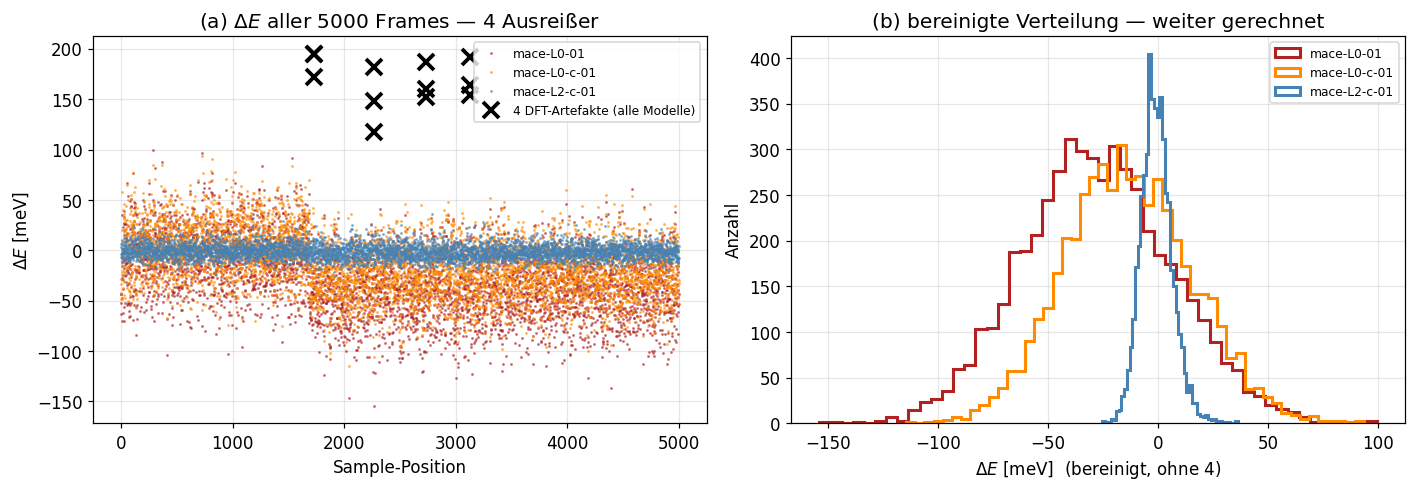

In [9]:
# --- Grosser Datensatz n=5000 (dieselben Strukturen fuer alle Modelle) ---
MODELS_FULL = {
    "mace-L0-01":   "single_mace-L0-01_testfull_n5000.npz",
    "mace-L0-c-01": "single_mace-L0-c-01_testfull_n5000.npz",
    "mace-L2-c-01": "single_mace-L2-c-01_testfull_n5000.npz",
}
COL_FULL = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "mace-L2-c-01": "steelblue"}

# 4 fehlerhafte DFT-Frames ueber die praezise L2-Referenz identifizieren (dE > 0.1 eV,
# klar abgesetzt vom Rest). Gilt fuer ALLE Modelle, da gleiche Strukturen.
_e_dft, _e_l2 = load_energies(CACHE / MODELS_FULL["mace-L2-c-01"])
_dE_l2 = _e_dft - _e_l2
BAD = _dE_l2 > 0.10                                  # Maske ueber die 5000
print(f"{BAD.sum()} Ausreisser (dE > 0.1 eV) identifiziert -> ausgeschlossen "
      f"(verbleibend: {(~BAD).sum()} Frames)\n")

# Beleg: an den 4 Frames liegen ALLE Modelle nahezu gleich weit daneben (-> DFT, nicht Modell)
_bad_pos = np.where(BAD)[0]
_idx = np.load(CACHE / MODELS_FULL["mace-L2-c-01"])["idx"][_bad_pos]
print("dE [eV] an den Ausreissern — alle Modelle nahezu gleich falsch:")
print(f"  {'Frame':>7}" + "".join(f"{m:>14}" for m in MODELS_FULL))
for r, fr in enumerate(_idx):
    row = []
    for m in MODELS_FULL:
        ed, em = load_energies(CACHE / MODELS_FULL[m])
        row.append(ed[_bad_pos[r]] - em[_bad_pos[r]])
    print(f"  {fr:>7}" + "".join(f"{v:>14.4f}" for v in row))

def load_full(name, clean=True):
    # e_dft, e_mace des n5000-Satzes; clean=True entfernt die 4 DFT-Artefakte
    e_dft, e_mace = load_energies(CACHE / MODELS_FULL[name])
    m = ~BAD if clean else np.ones(e_dft.size, bool)
    return e_dft[m], e_mace[m]

# --- Ausreisser einmal zeigen ---
import matplotlib.pyplot as plt
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.6))
for m, col in COL_FULL.items():
    e_dft, e_mace = load_energies(CACHE / MODELS_FULL[m])
    ax.plot(np.arange(e_dft.size), (e_dft - e_mace) * 1000, ".", ms=2, alpha=0.5,
            color=col, label=m)
for k, m in enumerate(MODELS_FULL):                 # Ausreisser ALLER Modelle markieren
    ed, em = load_energies(CACHE / MODELS_FULL[m])
    ax.plot(np.where(BAD)[0], (ed - em)[BAD] * 1000, "x", ms=11, mew=2.5, color="k",
            label=f"{BAD.sum()} DFT-Artefakte (alle Modelle)" if k == 0 else None)
ax.set_xlabel("Sample-Position"); ax.set_ylabel("$\\Delta E$ [meV]")
ax.set_title("(a) $\\Delta E$ aller 5000 Frames — 4 Ausreißer"); ax.legend(fontsize=8)
ax.grid(alpha=0.3)
for m, col in COL_FULL.items():
    e_dft, e_mace = load_full(m)                     # bereinigt
    bx.hist((e_dft - e_mace) * 1000, bins=50, histtype="step", lw=2, color=col, label=m)
bx.set_xlabel("$\\Delta E$ [meV]  (bereinigt, ohne 4)"); bx.set_ylabel("Anzahl")
bx.set_title("(b) bereinigte Verteilung — weiter gerechnet"); bx.legend(fontsize=8)
bx.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<a id="1"></a>
## 1. Fragestellung und Überblick

### 1.1 Der Reweighting-Kontext

Eine MD auf einem MACE-Potential erzeugt Konfigurationen $R_i$. Thermodynamische
Mittelwerte, die man eigentlich auf DFT-Niveau haben will, lassen sich aus dieser MD
per **Reweighting** gewinnen:

$$\langle A\rangle_\text{DFT} \;\approx\; \frac{\sum_i A_i\,w_i}{\sum_i w_i},
\qquad w_i = e^{-\beta\,(E_\text{DFT}(R_i)-E_\text{MACE}(R_i))} = e^{-\beta\,\Delta E_i}.$$

Jedes Gewicht $w_i$ verlangt eine DFT-Einzelpunktrechnung $E_\text{DFT}(R_i)$. Das ist
der teure Schritt.

Wie viel die Reweighting-Summe statistisch wert ist, misst die **effektive
Stichprobengröße** (Kish):

$$N_\text{eff} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}, \qquad 1 \le N_\text{eff} \le n.$$

Sind alle Gewichte gleich, ist $N_\text{eff}=n$; dominiert ein einzelnes Gewicht, ist
$N_\text{eff}=1$ — man hätte $n$ DFT-Rechnungen bezahlt und statistisch den Wert von
*einer*.

### 1.2 Die Qualitätsfrage

Der statistische Fehler eines reweighteten Mittelwerts skaliert wie
$1/\sqrt{N_\text{eff}}$. Das Verhältnis $N_\text{eff}/n$ ist damit direkt der Faktor, um
den das Reweighting die Fehlerbalken aufbläht:

$$\frac{\sigma_\text{reweighted}}{\sigma_\text{ideal}} = \frac{1}{\sqrt{N_\text{eff}/n}}.$$

Das Effizienzkriterium ist eine Schwelle $R$:

$$\frac{N_\text{eff}}{n} \;\ge\; R \qquad (\text{z.B. } R=0.8 \;\Leftrightarrow\; \text{höchstens }12\,\%\text{ breitere Fehlerbalken}).$$

$R$ ist ein **freier Parameter** des Verfahrens — welchen Wert er haben soll, ist nicht
Gegenstand dieses Notebooks.

Die folgende Abbildung zeigt den Unterschied zwischen einem gutartigen und einem
entarteten Reweighting an den realen Gewichtsverteilungen.

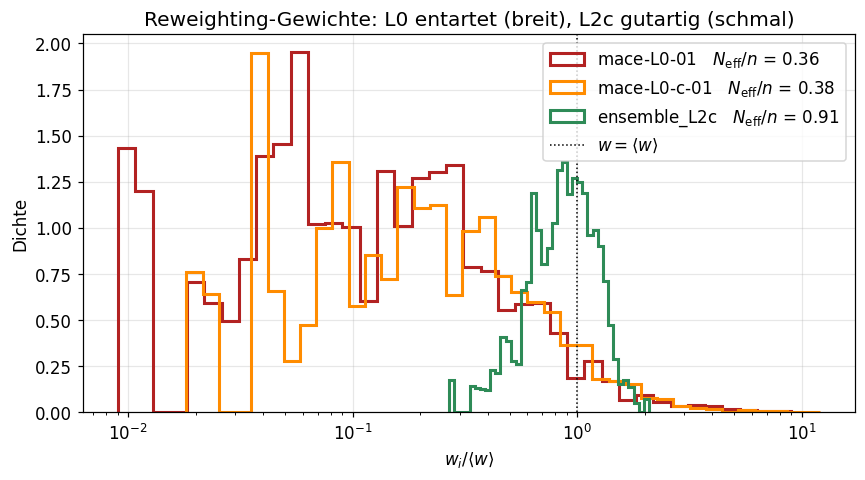

In [10]:
# Motivation: gutartige vs. entartete Gewichtsverteilung (reale Daten)
import numpy as np
import matplotlib.pyplot as plt

show = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange",
        "ensemble_L2c": "seagreen"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, col in show.items():
    e_dft, e_mace = load_energies(CACHE / MODELS[m])
    w = reweighting_weights(e_dft, e_mace, beta); w = w / w.mean()
    ne = effective_sample_size(w) / w.size
    wn = w[w > 0]
    bins = np.logspace(np.log10(wn.min()), np.log10(wn.max()), 40)
    ax.hist(wn, bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"{m}   $N_\\mathrm{{eff}}/n$ = {ne:.2f}")
ax.axvline(1.0, color="k", ls=":", lw=1, label="$w=\\langle w\\rangle$")
ax.set_xscale("log")
ax.set_xlabel("$w_i / \\langle w\\rangle$"); ax.set_ylabel("Dichte")
ax.set_title("Reweighting-Gewichte: L0 entartet (breit), L2c gutartig (schmal)")
ax.legend(); plt.tight_layout(); plt.show()

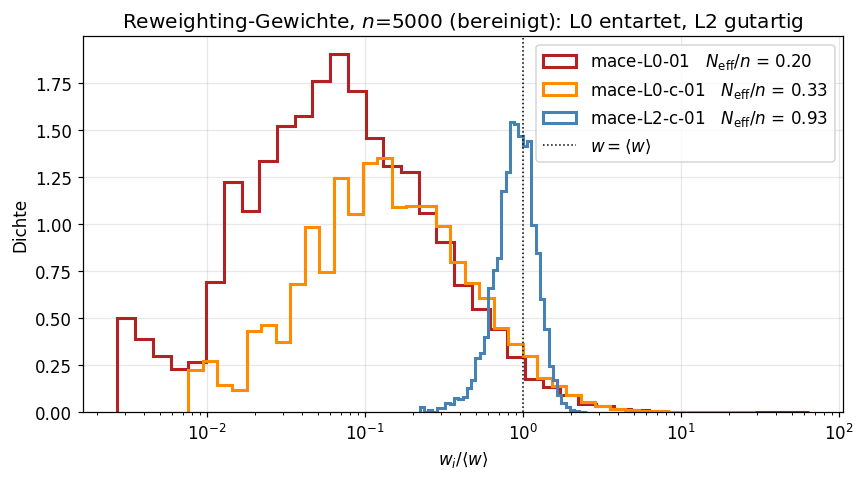

In [11]:
# dasselbe auf dem grossen Satz (n=5000, bereinigt) — SEPARATER Plot neben dem 400er
show_full = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange",
             "mace-L2-c-01": "steelblue"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, col in show_full.items():
    e_dft, e_mace = load_full(m)                     # bereinigt (ohne die 4 DFT-Artefakte)
    w = reweighting_weights(e_dft, e_mace, beta); w = w / w.mean()
    ne = effective_sample_size(w) / w.size
    wn = w[w > 0]
    bins = np.logspace(np.log10(wn.min()), np.log10(wn.max()), 40)
    ax.hist(wn, bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"{m}   $N_\\mathrm{{eff}}/n$ = {ne:.2f}")
ax.axvline(1.0, color="k", ls=":", lw=1, label="$w=\\langle w\\rangle$")
ax.set_xscale("log")
ax.set_xlabel("$w_i / \\langle w\\rangle$"); ax.set_ylabel("Dichte")
ax.set_title("Reweighting-Gewichte, $n$=5000 (bereinigt): L0 entartet, L2 gutartig")
ax.legend(); plt.tight_layout(); plt.show()

Die **L0**-Verteilungen sind über mehrere Größenordnungen gespreizt — wenige Frames
tragen fast das ganze Gewicht, $N_\text{eff}/n \approx 0.36$. Die **L2c**-Referenz ist
scharf um 1 konzentriert, $N_\text{eff}/n \approx 0.91$. Für die L0-Modelle ist das
Reweighting also statistisch schwach — und genau das möchte man **früh** erkennen.

### 1.3 Warum gerade L0 — die Kostenlogik

Entscheidend ist, welcher Teil der Rechnung teuer ist:

| Modell | MD | DFT | teurer Teil | frühes DFT-Abbrechen |
|---|---|---|---|---|
| **L2** (groß, langsam) | hoch | mittel | MD | bringt wenig |
| **L0** (klein, schnell) | niedrig | mittel | **DFT** | **spart real** |

Bei **L0** ist die MD billig, also dominieren die DFT-Einzelpunkte die Kosten. Man rechnet
sie **nacheinander auf Frames der laufenden MACE-MD** und erkennt früh, ob das Reweighting
tragen wird; ist es aussichtslos, bricht man ab und spart den Großteil der DFT-Kampagne. Das
ist der von Tobi genannte Anwendungsfall. Der „Testsatz“ wird dabei nicht separat erzeugt, sondern **Stück für Stück
während der MD gebaut**; die $k$ Frames sind ein wachsender Anfang der Produktionsdaten. Weil sie aus der MD selbst stammen, ist $p_\text{test}=p_\text{MACE}$; ein Reweighting
zwischen Verteilungen entfällt (§3).

> $n=5000$ (die Zahl der Reweighting-Frames) liegt durch das Volumen-Resampling fest.
> Reduziert wird **nicht** dieses finale $n$, sondern der DFT-Aufwand für die
> **Entscheidung**, ob sich der volle Lauf überhaupt lohnt.

### 1.4 Die Kernidee

$N_\text{eff}$ ist eine Funktion der $\Delta E_i$. Ihre Verteilung fasst **ein einziger
dimensionsloser Parameter** zusammen:

$$\boxed{\,c = \beta\cdot\mathrm{std}(\Delta E)\,}$$

Unter mild(en) Annahmen (Abschnitt 2) gilt $N_\text{eff}/n \approx e^{-c^2}$, das
Effizienzkriterium wird also zu einer **harten Schranke an $c$**:

$$\frac{N_\text{eff}}{n} \ge R \quad\Longleftrightarrow\quad c \le c_\text{max} = \sqrt{-\ln R}.$$

$c$ konvergiert schnell mit der Zahl der gerechneten DFT-Punkte $k$. Deshalb steht das
Urteil **PASS / FAIL** oft schon nach wenigen Punkten fest — das ist die Auszahlung für
L0. Die Konvergenz von $c$ (und der Formkorrekturen $\gamma_1,\gamma_2$) bei kleinem $k$
ist damit die zentrale Größe dieses Notebooks.

### 1.5 Was die vorhandenen Daten testen — und was nicht

Der Workflow wird hier auf einem **festen** DFT-Datensatz getestet (Strukturen aus einer
L2-MD, mit DFT-Referenz). Zwei Fragen sind streng zu trennen:

- **Stabilität der Methode** — konvergieren die Schätzer, entscheidet die Regel korrekt und
  früh, wie hoch ist die Fehlentscheidungsrate. Das hängt nur von der Folge der $\Delta E$-Werte
  ab; woher die Strukturen stammen, ist dem Schätzer egal. **Auf diesen Daten voll prüfbar.**
- **Güte eines konkreten L0-Modells** — welches $N_\text{eff}$ ein echter L0-Produktionslauf
  hätte. Das verlangt Strukturen aus der L0-MD ($p_\text{L0}$); die vorliegenden stammen aber
  aus einer L2-MD, die L0-MD hätte andere besucht. **Auf diesen Daten nicht bestimmbar** — und
  auch nicht durch Umgewichtung reparierbar (Fehlerfortpflanzung, §3).

**Konsequenz.** Dieses Notebook validiert die **Methodik** — nicht die Modellgüte eines
bestimmten L0-Laufs. Die $N_\text{eff}$-Zahlen der L0-Modelle hier zeigen, dass die Maschine
sie korrekt und früh als (un)tauglich einstuft; sie sind **keine** Prognose für einen realen
L0-Produktionslauf. Dessen $N_\text{eff}$ ergibt sich erst aus dem Lauf selbst, in dem
Screening und Messung zusammenfallen (§3) — dann ist es eine direkte Messung, keine
Vorhersage über eine Verteilungslücke hinweg.

### 1.6 Fahrplan

- **§2–3** — Formalismus (Kumulantenentwicklung) und die drei Annahmen A1–A3.
- **§4–5** — die $\Delta E$-Verteilung und die drei Diagnosegrößen $c$, $\hat k$, $N_\text{eff}$.
- **§6–7** — Konvergenz der Momente und die Entscheidungsschranke (Gauß vs. schiefe-korrigiert).
- **§8** — der sequenzielle Workflow: wie früh das L0-Urteil steht, wie viel DFT gespart wird.
- **§9–11** — Existenz von $N_\text{eff}$, Verifikation gegen bekannte Wahrheit, Grenzen (Abdeckung, iid).
- **§12** — Zusammenfassung und offene Fragen.

<a id="2"></a>
## 2. Der Formalismus: $c$ und die Kumulantenentwicklung

Ziel dieses Abschnitts: $N_\text{eff}/n$ auf **einen** dimensionslosen Parameter
zurückführen und die dabei gemachten Annahmen exakt benennen. Der Grundgedanke —
$\beta\,\sigma_{\Delta U}$ als Konvergenzmaß eines exponentiellen Mittels — stammt aus
der Freie-Energie-Störungstheorie [Zwanzig 1954] und der Phasenraum-Überlapp-Analyse
[Wu & Kofke 2005]; neu ist hier die systematische Formkorrektur über die Kumulanten.

### 2.1 $N_\text{eff}$ als Momentverhältnis

Die effektive Stichprobengröße [Kish 1965] ist

$$N_\text{eff} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}.$$

Teilt man Zähler und Nenner durch $n^2$ bzw. $n$ und nutzt das Gesetz der großen Zahlen,
konvergieren die Stichprobenmittel gegen Erwartungswerte:

$$\frac{N_\text{eff}}{n} = \frac{\bar w^{\,2}}{\overline{w^2}}
\;\xrightarrow[n\to\infty]{}\; \frac{E[w]^2}{E[w^2]}. \tag{2.1}$$

> **Annahme (i):** der Grenzübergang $n\to\infty$. Auf endlich vielen vorliegenden
> Gewichten ist $N_\text{eff}/n = (\sum w)^2/(n\sum w^2)$ dagegen **exakt** — eine reine
> Funktion der Gewichte, ohne Modell. Gleichung (2.1) wird nur zum *Extrapolieren*
> gebraucht.

### 2.2 Der Parameter $c$

Schreibe $\Delta E = \mu + \sigma z$ mit standardisiertem $z$ ($E[z]=0$, $\mathrm{Var}(z)=1$)
und definiere

$$c = \beta\,\sigma = \beta\cdot\mathrm{std}(\Delta E).$$

Jedes Gewicht faktorisiert damit in einen **für alle Frames gleichen** Vorfaktor und einen
frame-abhängigen Rest:

$$w_i = e^{-\beta\Delta E_i}
     = \underbrace{e^{-\beta\mu}}_{\text{konstant in }i}\cdot
       \underbrace{e^{-c z_i}}_{=\,v_i,\ \text{trägt Index }i}. \tag{2.2}$$

**Der Offset kürzt sich schon in der endlichen Summenform heraus** — ohne Erwartungswert,
ohne Grenzübergang. In die Kish-Formel eingesetzt:

$$\frac{N_\text{eff}}{n}
= \frac{\left(\sum_i w_i\right)^2}{n\sum_i w_i^2}
= \frac{\left(\sum_i e^{-\beta\mu}\,v_i\right)^2}{n\sum_i e^{-2\beta\mu}\,v_i^2}.$$

Weil $e^{-\beta\mu}$ **nicht von $i$ abhängt**, ist es in jedem Summanden derselbe Faktor
und lässt sich vor die Summe ziehen; $v_i=e^{-cz_i}$ dagegen ist für jeden Frame anders und
bleibt mit seinem Index **in** der Summe:

$$= \frac{\big(e^{-\beta\mu}\big)^2\left(\sum_i v_i\right)^2}{e^{-2\beta\mu}\;n\sum_i v_i^2}
= \frac{e^{-2\beta\mu}}{e^{-2\beta\mu}}\cdot\frac{\left(\sum_i v_i\right)^2}{n\sum_i v_i^2}
= \frac{\left(\sum_i v_i\right)^2}{n\sum_i v_i^2}.$$

Der Faktor $e^{-2\beta\mu}$ steht identisch in Zähler und Nenner und fällt weg — **exakt,
für jede endliche Stichprobe, annahmefrei.**

> **Warum die $v_i$ den Index behalten und $e^{-\beta\mu}$ nicht.**
> $\mu=\langle\Delta E\rangle$ ist eine *einzige Zahl* für den ganzen Datensatz, also in
> $e^{-\beta\mu}$ für jeden Frame gleich — ein gemeinsamer Faktor, der aus der Summe
> herausgezogen werden kann. $z_i=(\Delta E_i-\mu)/\sigma$ ist dagegen der
> *standardisierte Wert des Frames $i$* und variiert von Frame zu Frame; $v_i=e^{-cz_i}$
> trägt diese Variation und muss deshalb mit dem Index **im** Summanden bleiben.

**Prinzip: Skaleninvarianz.** Multipliziert man alle Gewichte mit derselben Konstante
$\lambda$, ändert sich

$$\frac{\big(\sum_i \lambda w_i\big)^2}{\sum_i (\lambda w_i)^2}
= \frac{\lambda^2\big(\sum_i w_i\big)^2}{\lambda^2\sum_i w_i^2}
= \frac{\big(\sum_i w_i\big)^2}{\sum_i w_i^2}$$

nicht — $\lambda^2$ kürzt sich stets. Ein additiver Energie-Offset ist genau so ein Faktor
($\lambda=e^{-\beta\mu}$) und damit für $N_\text{eff}$ unsichtbar. Dasselbe Argument gilt
für den Variationskoeffizienten $\mathrm{CV}=\mathrm{std}(w)/\langle w\rangle$ und den
Tail-Index $\hat k$.

**Im Grenzwert** $n\to\infty$ (Gl. 2.1) werden die Summenmittel zu Erwartungswerten der
standardisierten Variable:

$$\frac{N_\text{eff}}{n} \;\xrightarrow[n\to\infty]{}\; \frac{E[e^{-c z}]^2}{E[e^{-2c z}]}. \tag{2.3}$$

$N_\text{eff}/n$ hängt also nur von der **Form** der Verteilung (über $z$) und der
**Skala** $c$ ab, nicht vom Mittelwert. Dass genau **ein** Parameter $c$ übrig bleibt,
erzwingt schon die Dimensionsanalyse ($\beta\Delta E$ ist dimensionslos).

### 2.3 Die kumulantenerzeugende Funktion

**Warum dieses Werkzeug.** Der Ausdruck (2.3) enthält nur noch Größen der Form
$E[e^{t z}]$ — das ist die **momenterzeugende Funktion** (MGF) $M(t)=E[e^{t z}]$,
ausgewertet an $t=-c$ und $t=-2c$. Ihr Logarithmus,

$$K(t) = \log M(t) = \log E[e^{t z}],$$

heißt **kumulantenerzeugende Funktion** (CGF). Der Logarithmus ist der entscheidende
Schritt: er verwandelt das Verhältnis von Momenten in (2.3) in eine **Differenz**, und
seine Taylor-Koeffizienten sind gerade die Zahlen, die die Form der Verteilung beschreiben.

**Kumulanten statt Momente.** Entwickelt man $K$ um $t=0$,

$$K(t) = \sum_{m\ge 1}\frac{\kappa_m}{m!}\,t^m,$$

so sind die Koeffizienten $\kappa_m$ die **Kumulanten** von $z$ — nicht die (Roh-)Momente.
Die niedrigsten hängen mit den zentralen Momenten zusammen:

$$\kappa_1 = E[z], \quad \kappa_2 = \mathrm{Var}(z), \quad
  \kappa_3 = E[(z-\bar z)^3], \quad \kappa_4 = E[(z-\bar z)^4] - 3\,\kappa_2^2.$$

Für die **standardisierte** Variable $z$ (Mittel 0, Varianz 1, §2.2) wird das besonders
einfach:

$$\kappa_1 = 0,\quad \kappa_2 = 1,\quad \kappa_3 = \gamma_1\ (\text{Schiefe}),\quad
  \kappa_4 = \gamma_2\ (\text{Exzess-Kurtosis}),$$

also

$$K(t) = \tfrac{1}{2}t^2 + \tfrac{\gamma_1}{6}t^3 + \tfrac{\gamma_2}{24}t^4 + \dots$$

**Zwei Eigenschaften, die den Formalismus tragen:**

- Für eine **Normalverteilung** sind alle $\kappa_m$ mit $m\ge 3$ exakt null, d.h.
  $K(t)=\tfrac12 t^2$. Das ist der tiefere Grund, warum der Gauß-Fall gleich nur $-c^2$
  liefert (§2.4): jede Abweichung von Gauß steckt ausschließlich in $\gamma_1,\gamma_2,\dots$
- Kumulanten sind **additiv** für Summen unabhängiger Beiträge. Weil $\Delta E$ eine Summe
  lokaler Beiträge über die Atome/Moleküle ist, steuert diese Eigenschaft später die
  Skalierung mit der Systemgröße (§3).

> **Wessen Verteilung ist das?** $K$ ist die CGF von $z$, also der **standardisierten
> $\Delta E$-Verteilung** — *nicht* der Gewichtsverteilung $w$. Man beachte
> $\log w_i = -\beta\mu - c\,z_i$: $\log w$ ist eine **affine** Funktion von $z$, die
> Kumulanten von $z$ sind also (bis auf Ort und Skala) die von $\log w$ — aber **nicht**
> die von $w$ selbst. Die $w$-Momente entstehen erst durch **Auswertung** von $K$ an festen
> Stellen (gleich unten). Kurz: $\gamma_1,\gamma_2,c$ beschreiben die **Form** von
> $\Delta E$; aus $w$ kommen die **Momente** (hier) und der **Tail** ($\hat k$, §9).

**Einsetzen in (2.3).** Aus der Definition $K(t)=\log E[e^{t z}]$ folgt unmittelbar
$E[e^{t z}] = e^{K(t)}$. An den beiden benötigten Stellen:

$$E[e^{-c z}] = e^{K(-c)}, \qquad E[e^{-2c z}] = e^{K(-2c)}.$$

Damit wird das Verhältnis (2.3) zu einer Differenz von CGF-Werten — der Logarithmus macht
aus dem Quadrat einen Faktor 2 und aus dem Bruch ein Minuszeichen:

$$\log\frac{N_\text{eff}}{n} = \log\frac{E[e^{-c z}]^2}{E[e^{-2c z}]}
= 2\,K(-c) - K(-2c). \tag{2.4}$$

Dieser Ausdruck ist **exakt** — keine Näherung, keine Gauß-Annahme —, solange $K(-c)$ und
$K(-2c)$ **existieren**, d.h. $E[e^{-c z}]$ und $E[e^{-2c z}]$ (äquivalent $E[w]$ und
$E[w^2]$) endlich sind. Genau diese Existenz prüft §9 über den Tail-Index $\hat k$.

### 2.4 Die Entwicklung und der Gauß-Term

Setzt man die Reihe für $K$ in (2.4) ein, so heben sich Zähler- und Nenner-Offset und man
erhält mit $(-2c)^m = (-1)^m 2^m c^m$:

$$\log\frac{N_\text{eff}}{n}
= \sum_{m\ge 2}\frac{\kappa_m}{m!}\,(-1)^m\,(2 - 2^m)\,c^m
= -c^2 + \gamma_1 c^3 - \tfrac{7}{12}\gamma_2 c^4 + O(c^5). \tag{2.5}$$

(Man prüfe die Vorfaktoren: $m=2$ gibt $(2-4)/2!=-1$; $m=3$ gibt $-(2-8)/3!=+1$; $m=4$
gibt $(2-16)/4!=-7/12$.)

**Gauß-Grenzfall.** Behält man nur $m=2$, so ist

$$\frac{N_\text{eff}}{n} \approx e^{-c^2}. \tag{2.6}$$

Für normalverteiltes $\Delta E$ ist (2.6) exakt (alle höheren $\kappa_m=0$). Das ist genau
die Kenngröße $\beta\sigma_{\Delta U}$ der FEP-Konvergenz [Zwanzig 1954] und äquivalent zu
`predicted_neff_gauss` im Code, da $c^2 = \beta^2\mathrm{Var}(\Delta E)$.

### 2.5 Konvergenz — der effektive Parameter ist $2c$

In (2.4) wird $K$ auch an $t=-2c$ ausgewertet. Der $m$-te Term skaliert daher wie
$\sim (2c)^m/m!$, nicht $c^m/m!$ — **der effektive Entwicklungsparameter ist $2c$**. Eine
brauchbare Restabschätzung ist

$$R_5 \approx \frac{(2c)^5}{5!}. \tag{2.7}$$

> **Annahme (ii) — A1 (§3.1):** die Reihe (2.5) konvergiert bei diesem $c$. Prüfbar über (2.7):
> ist $R_5\ll 1$, trägt die Entwicklung; ist $R_5=O(1)$, ist sie wertlos, und man nimmt
> den **exakten** Kish-Wert (der immer existiert, solange $E[w^2]<\infty$).

Die folgende Zelle prüft das an den realen Daten.

In [12]:
# Verifikation der Entwicklung (2.5) gegen den exakten Kish-Wert — 400 und 5000 getrennt
import numpy as np
from math import factorial

def expansion_terms(e_dft, e_mace):
    dE = e_dft - e_mace
    s = dE.std(ddof=1); u = dE - dE.mean()
    c  = beta * s
    g1 = float((u**3).mean() / s**3)
    g2 = float((u**4).mean() / s**4 - 3.0)
    kish  = effective_sample_size(reweighting_weights(e_dft, e_mace, beta)) / dE.size
    gauss = np.exp(-c**2)                                  # (2.6), nur -c^2
    three = np.exp(-c**2 + g1*c**3 - 7/12*g2*c**4)         # (2.5), 3 Terme
    R5    = (2*c)**5 / factorial(5)                        # (2.7)
    return c, g1, g2, kish, gauss, three, R5

def print_table(title, items):
    print(title)
    print(f"{'Modell':<14}{'c':>7}{'gamma1':>8}{'Kish':>8}{'Gauss':>8}"
          f"{'3-Term':>8}{'Rest 2c^5/5!':>14}{'  A2?':>7}")
    print("-" * 74)
    for m, (e_dft, e_mace) in items:
        c, g1, g2, kish, ga, th, R5 = expansion_terms(e_dft, e_mace)
        ok = "traegt" if R5 < 0.05 else "DIVERGENT"
        print(f"{m:<14}{c:>7.3f}{g1:>+8.3f}{kish:>8.3f}{ga:>8.3f}"
              f"{th:>8.3f}{R5:>14.3f}   {ok}")

print_table("n = 400  (testbig):",
            [(m, load_energies(CACHE / MODELS[m])) for m in MODELS])
print()
print_table("n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):",
            [(m, load_full(m)) for m in MODELS_FULL])

n = 400  (testbig):
Modell              c  gamma1    Kish   Gauss  3-Term  Rest 2c^5/5!    A2?
--------------------------------------------------------------------------
mace-L0-01      1.238  +0.247   0.361   0.216   0.304         0.774   DIVERGENT
mace-L0-c-01    1.079  +0.207   0.382   0.312   0.362         0.391   DIVERGENT
ensemble_L2c    0.327  +0.501   0.912   0.899   0.912         0.001   traegt
mace-L2-c-01    0.335  +0.413   0.907   0.894   0.907         0.001   traegt

n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):
Modell              c  gamma1    Kish   Gauss  3-Term  Rest 2c^5/5!    A2?
--------------------------------------------------------------------------
mace-L0-01      1.340  +0.090   0.196   0.166   0.228         1.152   DIVERGENT
mace-L0-c-01    1.146  +0.127   0.327   0.269   0.347         0.527   DIVERGENT
mace-L2-c-01    0.283  +0.422   0.929   0.923   0.929         0.000   traegt


**Lesart.** Für die **L2c**-Referenz ($c=0.33$) ist der Rest $\approx 0.001$: die
Entwicklung trägt, die 3-Term-Prognose trifft den exakten Kish-Wert auf $<0.1\,\%$. Für
die **L0**-Modelle ($c\approx1.1$–$1.2$) ist der Rest $0.4$–$0.8$: die Reihe divergiert,
die Polynomprognose liegt 6–17 % daneben.

Das ist **kein Problem für die Entscheidung** (§7–8): das FAIL-Urteil hängt an $c$ gegen
die Schwelle, nicht am genauen $N_\text{eff}$-Wert — und $c$ selbst ist robust (§7). Wo
man doch die Zahl braucht, nimmt man den exakten Kish-Wert.

### 2.6 Die Entscheidungsschranke für $c$

Das Effizienzkriterium $N_\text{eff}/n \ge R$ lässt sich mit (2.4)/(2.5) direkt in eine
**obere Schranke an $c$** übersetzen.

**Gauß-Fall.** Mit $N_\text{eff}/n \approx e^{-c^2}$:

$$e^{-c^2} \ge R
\;\Longleftrightarrow\; -c^2 \ge \ln R
\;\Longleftrightarrow\; c^2 \le -\ln R
\;\Longleftrightarrow\; c \le c_\text{max} = \sqrt{-\ln R}. \tag{2.8}$$

($\ln R < 0$ für $R<1$, die Wurzel ist also reell.) Für $R=0.8$ ist $c_\text{max}=0.472$.

**Mit Formkorrektur.** Aus der vollen Entwicklung (2.5), $\log(N_\text{eff}/n) =
-c^2+\gamma_1 c^3-\tfrac{7}{12}\gamma_2 c^4$, wird das Kriterium $\log(N_\text{eff}/n)\ge\ln R$
zu einer **Quartik**:

$$c^2 - \gamma_1 c^3 + \tfrac{7}{12}\gamma_2 c^4 \;\le\; -\ln R. \tag{2.9}$$

Die kleinste positive Lösung $c_\text{max}$ findet man numerisch (Nullstellensuche, `brentq`).
Bei **Rechtsschiefe** ($\gamma_1>0$) liegt sie **höher** als die Gauß-Schranke — man darf mehr
$c$ zulassen. Die Gauß-Version ist also **konservativ** (lehnt im Zweifel eher ab, nie
fälschlich an); bei Linksschiefe kehrt sich das um. Die Konsequenz — die *Falsch-FAIL-Zone*
zwischen beiden Schranken — behandelt §7.

**Selbstkonsistenz — die Schranke erbt A1.** Die Quartik (2.9) stammt aus der *abgeschnittenen*
Reihe (2.5) und setzt daher deren **Konvergenz** voraus (A1, §3.1) — genau an der Stelle
$c_\text{max}$. Sie ist nur gültig, wo der Restterm dort klein ist,
$R_5\approx(2c_\text{max})^5/5!\ll 1$. Für die relevanten $R\in[0.7,0.9]$ liegt $c_\text{max}$
bei $0.35$–$0.68$, der Rest also unter $0.04$ — die schiefe-korrigierte Schranke ist dort
selbstkonsistent. Bei sehr kleinem $R$ (große Toleranz) wächst $c_\text{max}$ so weit, dass die
Reihe nicht mehr trägt; dann braucht man sie auch nicht: das Kriterium $N_\text{eff}/n\ge R$ ist
über den **exakten** Kish-Wert direkt prüfbar (annahmefrei, §2.1), und die exakte Schranke in
$c$ folgt aus $2K(-c)-K(-2c)=\ln R$ ohne jede Reihe. Der reine **Gauß**-Term (2.8) ist davon
unberührt — führender Term, kein Reihenschluss, und immer als (unter Rechtsschiefe konservative)
Formel verfügbar.

In [13]:
# Verifikation der Schranke c_max (Gauss vs. exakte Quartik)
import numpy as np
from scipy.optimize import brentq

e_dft, e_mace = load_energies(CACHE / MODELS["ensemble_L2c"])
dE = e_dft - e_mace
s = dE.std(ddof=1); u = dE - dE.mean()
g1 = float((u**3).mean() / s**3); g2 = float((u**4).mean() / s**4 - 3.0)

cmax_gauss = lambda R: np.sqrt(-np.log(R))                                 # (2.8)
cmax_exact = lambda R: brentq(lambda c: c**2 - g1*c**3 + 7/12*g2*c**4      # (2.9)
                              + np.log(R), 1e-4, 3.0)
R5 = lambda c: (2*c)**5 / 120.0                    # Restterm an c_max (Selbstkonsistenz)

print(f"gamma1 = {g1:+.3f},  gamma2 = {g2:+.3f}\n")
print(f"{'R':>5}{'c_max Gauss':>13}{'c_max exakt':>13}{'R5(c_max)':>12}")
for R in (0.7, 0.8, 0.9):
    ce = cmax_exact(R)
    print(f"{R:>5.1f}{cmax_gauss(R):>13.3f}{ce:>13.3f}{R5(ce):>12.3f}")

gamma1 = +0.501,  gamma2 = +0.390

    R  c_max Gauss  c_max exakt   R5(c_max)
  0.7        0.597        0.683       0.040
  0.8        0.472        0.529       0.011
  0.9        0.325        0.352       0.001


**Zur Nullstellensuche (`brentq`).** Die Quartik (2.9) lässt sich nicht geschlossen nach $c$
auflösen; `brentq` findet die Wurzel numerisch in einem Intervall $[a,b]$, an dessen Rändern
$f(c)=c^2-\gamma_1 c^3+\tfrac{7}{12}\gamma_2 c^4+\ln R$ das **Vorzeichen wechselt** ($f(a)\,f(b)<0$).

*Warum es einen Wechsel gibt.* Man kann $f$ schreiben als

$$f(c) = \ln R - \log\frac{N_\text{eff}}{n} = \log\!\left(\frac{R}{N_\text{eff}/n}\right),$$

also als Log-Quotient aus Ziel $R$ und erreichter Effizienz. Sein Vorzeichen **ist** die
Entscheidung: $f<0 \Leftrightarrow N_\text{eff}/n>R$ (PASS), $f>0 \Leftrightarrow$ FAIL. Bei
$c=0$ ist $N_\text{eff}/n=1$ (PASS, $f=\ln R<0$), bei großem $c$ geht $N_\text{eff}/n\to 0$
(FAIL, $f>0$) — dazwischen genau ein Nulldurchgang, die Schwelle $c_\text{max}$.

*Wie es funktioniert.* `brentq` kombiniert **Bisektion** (halbiert das Intervall und behält die
Hälfte mit dem Vorzeichenwechsel — garantiert, aber linear langsam) mit **Interpolation**
(Sekante bzw. inverse Parabel durch die letzten Punkte — schnell, aber ohne Sicherung riskant).
Eine Schutzregel akzeptiert den schnellen Schritt nur, wenn er im Intervall bleibt und dieses
ausreichend verkleinert; sonst wird bisektiert. So ist die Konvergenz meist superlinear, aber
**nie schlechter als Bisektion** — die Wurzel geht nie aus dem Bracket verloren.

*Das Intervall $[10^{-4}, 3]$* ist das Suchfenster für $c$: die Untergrenze knapp über dem
physikalischen Minimum $0$, die Obergrenze weit jenseits jedes brauchbaren Modells
($c=3 \Leftrightarrow N_\text{eff}/n\approx 10^{-4}$). Für jedes sinnvolle $R$ liegt
$c_\text{max}$ sicher dazwischen, und die Vorzeichen an den Rändern stimmen. Weil das Fenster
nahe $0$ beginnt, wird die **erste** (kleinste) Nullstelle gefunden — genau das obere Ende des
PASS-Intervalls $[0, c_\text{max}]$.

**Lesart.** Rechtsschiefe hebt die Schranke um ~12 % (R=0.8: 0.472 → 0.529), und der
Restterm an $c_\text{max}$ bleibt klein ($\le 0.04$) — die korrigierte Schranke ist
selbstkonsistent. Für die **Entscheidung** genügt schon die Gauß-Schranke, weil die L0-Modelle
mit $c\approx1.1$–$1.2$ ohnehin **weit** darüber liegen; die Korrektur zählt nur bei einem
Modell nahe der Schwelle (§7).

### 2.7 Literatureinordnung

Der $c$-Formalismus ist **nicht neu**, sondern die auf den Modellfehler übertragene Form
etablierter Kriterien:

- **[Zwanzig 1954]** R. W. Zwanzig, *J. Chem. Phys.* **22**, 1420 — Freie-Energie-
  Störungstheorie; $\beta\sigma_{\Delta U}$ als Konvergenzmaß des exponentiellen Mittels.
- **[Kish 1965]** L. Kish, *Survey Sampling*, Wiley — die effektive Stichprobengröße
  $N_\text{eff}=(\sum w)^2/\sum w^2$.
- **[Wu & Kofke 2005]** D. Wu & D. A. Kofke, *J. Chem. Phys.* **123**, 054103 & 084109 —
  Phasenraum-Überlapp, Bias-Maß über $\sigma_{\Delta U}$, **explizit unter Gauß-Annahme**
  (genau die Lücke, die der $\gamma_1 c^3$-Term schließt).
- **[Kofke 2002]** D. A. Kofke, *J. Chem. Phys.* **117**, 6911 — Akzeptanzrate im Replica
  Exchange aus dem Energieverteilungs-Überlapp; strukturell dieselbe Bedingung
  $c\le c_\text{max}$.
- **[Vehtari et al. 2024]** A. Vehtari, D. Simpson, A. Gelman, Y. Yao, J. Gabry, *JMLR*
  **25** — Pareto-Smoothed Importance Sampling; der Tail-Index $\hat k$ (§9).
- **[Ferrenberg & Swendsen 1989]** *Phys. Rev. Lett.* **63**, 1195 — Histogramm-
  Reweighting; Extrapolationsbereich schrumpft wie $1/\sqrt N$.

*Numerisches Werkzeug:* **[Brent 1973]** R. P. Brent, *Algorithms for Minimization without
Derivatives*, Prentice-Hall (Kap. 4) — das in §2.6 verwendete Nullstellenverfahren
`scipy.optimize.brentq` (Bisektion, abgesichert mit Sekante und inverser quadratischer
Interpolation).

**Vermutlich neu — im Projekt entstanden und *nicht* gegen Literatur geprüft:**
$\gamma_1 c^3$ als quantitatives Gültigkeitskriterium des Gauß-$N_\text{eff}$-Prädiktors.
Die Bausteine sind Standard; vor einer Neuheitsbehauptung im Bericht gezielt
nachrecherchieren.

<a id="3"></a>
## 3. Die zwei Annahmen (A1–A2)

Der Kern des Verfahrens ist **exakt**: $N_\text{eff}/n = (\sum_i w_i)^2/(n\sum_i w_i^2)$ ist
eine Funktion der Gewichte, kein Modell (§2.1). Der Workflow ist bewusst für die **iterative
Schätzung auf dem Produktionsstrom selbst** gebaut: die $\Delta E$-Frames sind Teil der
laufenden L0-MD ($p_\text{test}=p_\text{MACE}$, §1.3), Screening und Messung fallen zusammen.

> **Kein Reweighting zwischen Verteilungen.** Man könnte einen fremd-gesampelten Testsatz per
> Umgewichtung auf die Produktionsverteilung umrechnen. Das ist hier **bewusst nicht** der
> Weg: die doppelte Umgewichtung pflanzt Fehler fort und ist statistisch teuer. Weil die
> Frames ohnehin aus der Produktions-MD stammen, entfällt jeder solche Transfer.

Damit ruht das Verfahren auf **genau zwei** Annahmen:

| | Annahme | Status | wo geprüft |
|---|---|---|---|
| **A1** | die Kumulantenreihe konvergiert bei diesem $c$ | prüfbar über den Restterm | §2.5, §3.1 |
| **A2** | der wachsende Frame-Bestand **deckt ab**, wo die MD hinläuft | am endlichen $k$ nicht abschließend prüfbar → überwachen | §3.2, §11 |

### 3.1 A1 — Konvergenz der Kumulantenreihe

Die Prognose $N_\text{eff}/n$ **aus $c$** nutzt die Entwicklung (2.5). Sie konvergiert nur,
wenn $2c$ innerhalb des Konvergenzradius der CGF liegt (§2.5) — prüfbar über den Restterm
$R_5\approx(2c)^5/5!$.

- **L2c** ($c=0.33$): $R_5\approx0.001$, die Reihe trägt, Prognose auf $<0.1\,\%$.
- **L0** ($c\approx1.1$–$1.2$): $R_5\approx0.4$–$0.8$, die Reihe **divergiert**, Prognose 6–17 % daneben.

**Bricht A1, ist das kein Beinbruch.** Auf vorhandenen Gewichten ist der Kish-Wert exakt und
annahmefrei (§2.1) — die Reihe wird nur zum *Extrapolieren* aus $c$ gebraucht. Und die
**Entscheidung** (§7–8) hängt ohnehin nur an $c$ gegen die Schwelle, nicht am genauen
$N_\text{eff}$-Wert. A1 betrifft also nur die Bequemlichkeit, $N_\text{eff}$ aus $c$
vorherzusagen, nicht die Messbarkeit.

### 3.2 A2 — Abdeckung (Repräsentativität der bisherigen $w_i$)

**Was A2 verlangt.** Die bis zum Punkt $k$ gezogenen Gewichte $w_1,\dots,w_k$ müssen die
**volle Verteilung** der $w_i$ repräsentieren — insbesondere ihren Tail. Denn $N_\text{eff}$
wird von den größten Gewichten bestimmt; fehlt der Tail in der bisherigen Stichprobe, ist die
Schätzung zu optimistisch. Ein sehr großes $w_i$ entsteht aus einer Konfiguration mit stark
negativem $\Delta E$ — einer Struktur, die MACE deutlich zu günstig einschätzt.

**Die Gefahr ist die Reihenfolge.** Ein solches seltenes großes Gewicht kann unter den ersten
$k$ Frames noch fehlen (Metastabilität — die MD hängt anfangs in einem gutartigen Becken) und
bei größerem $k$ nachträglich auftauchen, wodurch $N_\text{eff}$ noch fällt. Die bis $k$
gesehenen $w_i$ könnten den Rand der Verteilung also schlicht noch nicht abgetastet haben.

**Warum an endlichem $k$ nicht abschließend prüfbar.** Die Existenz von $N_\text{eff}$
($E[w^2]<\infty$) ist äquivalent dazu, dass $w$ **beschränkt** ist. Das ist eine Aussage über
den **ungesehenen Rand**: dass die $k$ beobachteten Gewichte ein endliches Maximum haben, ist
**kein** Beweis für die Beschränktheit der Verteilung — das Sample-Maximum ist immer endlich,
egal wie schwer der Tail ist. Ein größeres $w$ kann bei größerem $k$ noch kommen.

**Wo A2 hingehört: ins Weiterbeobachten.** Weil die $w_i$ ein **wachsender Datenstrom** sind,
ist die Prüfung Teil des Verfahrens selbst: laufendes $\hat k$ oder, billiger, CV-Drift und
Max-Einfluss, **während $k$ wächst** — steigt eines systematisch, hat man gerade einen bis
dahin ungesehenen Teil der $w$-Verteilung erreicht (der „Frame-800-Fall"). §11 zeigt die
Nachweisgrenze und die Diagnosen numerisch.

> Die Kernaussage bleibt **konditional**: *unter der Bedingung, dass die bis $k$ gezogenen
> $w_i$ die volle Verteilung repräsentieren*, sind die Schätzer brauchbar. Diese Bedingung
> prüft man durch **Weiterbeobachten** des wachsenden Stroms.

<a id="4"></a>
## 4. Die Verteilung von $\Delta E$

§2 hat $c,\gamma_1,\gamma_2$ als Formparameter der $\Delta E$-Verteilung *formal*
eingeführt. Hier schauen wir sie **empirisch** an: Wie sieht die Verteilung aus, ist sie
gaußisch, und — die entscheidende Frage — wie hängt ihre Form mit der Brauchbarkeit des
Gauß-Terms zusammen.

> **Scope (§1.5).** Die $\Delta E$ sind auf den vorliegenden (L2-gesampelten) Frames gerechnet.
> §4 untersucht damit die **Form der Daten**, mit denen die Schätzer arbeiten — nicht die wahre
> L0-Produktionsverteilung.

### 4.1 Die $\Delta E$-Verteilung (400 vs. 5000)

Die zentrierten $\Delta E$ (der Offset $\mu$ ist bedeutungslos, §2.2) für **beide** Datensätze
nebeneinander. Man sieht die **Skala**: L0 streut breit ($c\approx1.2$–$1.3$), L2 schmal
($c\approx0.3$). Die **Form** ($\gamma_1,\gamma_2$) steht in den Tabellen — sie ist der
Schlüssel zu 4.2/4.3.

n = 400 (testbig):
Modell                c   gamma1   gamma2  std(dE)[meV]
mace-L0-01        1.238   +0.247   +0.094         31.14
mace-L0-c-01      1.079   +0.207   +0.140         27.16
ensemble_L2c      0.327   +0.501   +0.390          8.22

n = 5000 (bereinigt):
Modell                c   gamma1   gamma2  std(dE)[meV]
mace-L0-01        1.340   +0.090   -0.053         33.72
mace-L0-c-01      1.146   +0.127   -0.062         28.84
mace-L2-c-01      0.283   +0.422   +0.821          7.13


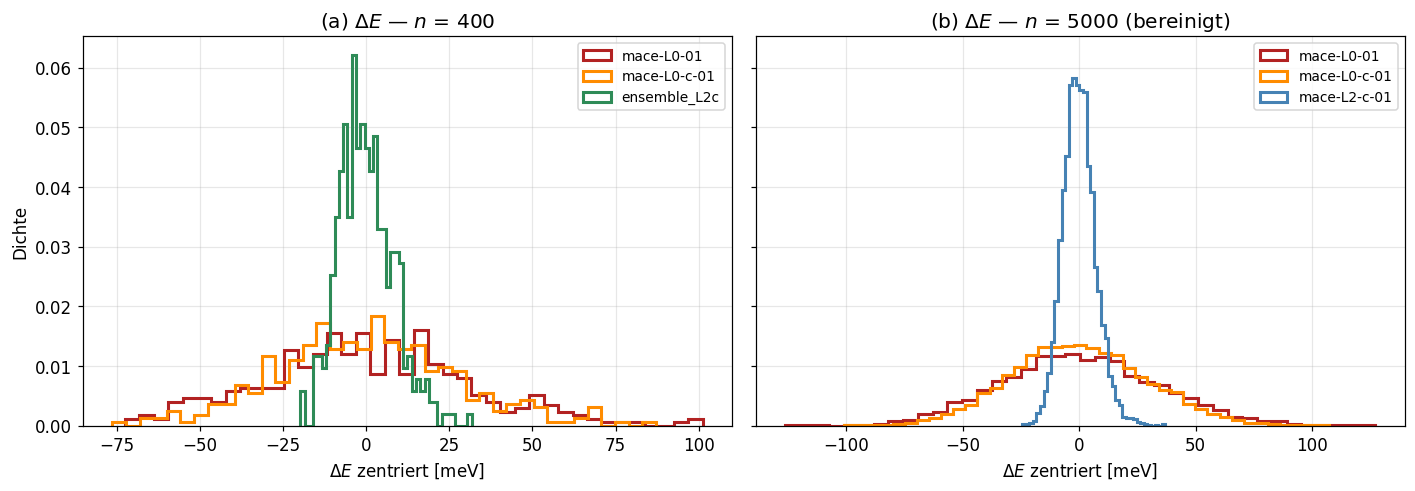

In [14]:
import numpy as np
import matplotlib.pyplot as plt

SHOW_400  = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "ensemble_L2c": "seagreen"}
SHOW_5000 = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "mace-L2-c-01": "steelblue"}
SHOW = SHOW_400          # Alias fuer die 400er-Folgeabschnitte (4.2, 4.3)

def moments_row(m, dE):
    s = dE.std(ddof=1); u = dE - dE.mean()
    g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4 - 3)
    print(f"{m:<15}{beta*s:>8.3f}{g1:>+9.3f}{g2:>+9.3f}{s*1000:>14.2f}")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)

print("n = 400 (testbig):")
print(f"{'Modell':<15}{'c':>8}{'gamma1':>9}{'gamma2':>9}{'std(dE)[meV]':>14}")
for m, col in SHOW_400.items():
    e_dft, e_mace = load_energies(CACHE / MODELS[m]); dE = e_dft - e_mace
    moments_row(m, dE)
    a.hist((dE-dE.mean())*1000, bins=40, density=True, histtype="step", lw=2, color=col, label=m)

print("\nn = 5000 (bereinigt):")
print(f"{'Modell':<15}{'c':>8}{'gamma1':>9}{'gamma2':>9}{'std(dE)[meV]':>14}")
for m, col in SHOW_5000.items():
    e_dft, e_mace = load_full(m); dE = e_dft - e_mace
    moments_row(m, dE)
    b.hist((dE-dE.mean())*1000, bins=40, density=True, histtype="step", lw=2, color=col, label=m)

a.set_xlabel("$\\Delta E$ zentriert [meV]"); a.set_ylabel("Dichte")
a.set_title("(a) $\\Delta E$ — $n$ = 400"); a.legend(fontsize=9); a.grid(alpha=0.3)
b.set_xlabel("$\\Delta E$ zentriert [meV]")
b.set_title("(b) $\\Delta E$ — $n$ = 5000 (bereinigt)"); b.legend(fontsize=9); b.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Ablesbar.** L2 ist **schmal**, aber (Tabelle) deutlich **rechtsschief** ($\gamma_1\approx0.4$–$0.5$).
Die L0-Modelle sind **breit**, ihre Form aber **näher an der Glocke** ($\gamma_1\approx0.1$–$0.2$).
Merke dir diesen Gegensatz — er ist der Schlüssel zu 4.3. Der große Satz (5000) bestätigt die
Skala und zeigt die L0-Verteilung sogar noch etwas breiter (größeres $c$), also die Entartung
klarer als die 400 Frames.

### 4.2 Ist $\Delta E$ gaußisch? — und warum die Frage in die Irre führt

Der QQ-Plot trägt die empirischen Quantile gegen die einer Normalverteilung auf (Gerade =
gaußisch); der Shapiro-Wilk-Test gibt ein $p$ dazu (klein = Normalität verworfen).

n = 400 (testbig):
Modell           Shapiro W      p-Wert      Normalität
mace-L0-01          0.9930    6.09e-02 nicht verworfen
mace-L0-c-01        0.9959    3.80e-01 nicht verworfen
ensemble_L2c        0.9850    3.67e-04       verworfen

n = 5000 (bereinigt):
Modell           Shapiro W      p-Wert      Normalität
mace-L0-01          0.9993    3.97e-02       verworfen
mace-L0-c-01        0.9988    9.62e-04       verworfen
mace-L2-c-01        0.9898    1.47e-18       verworfen


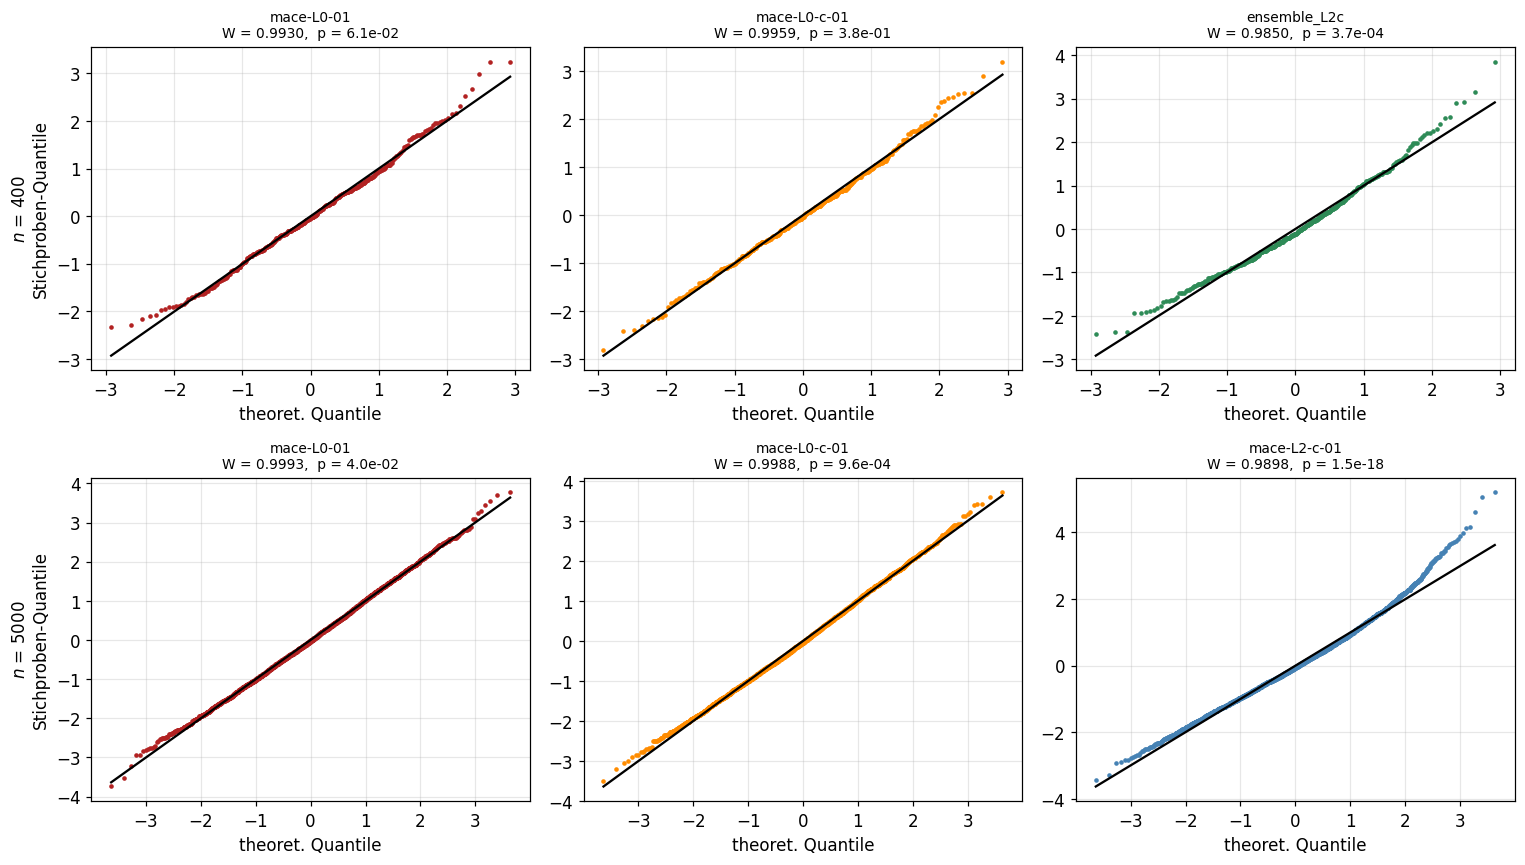

In [15]:
from scipy.stats import shapiro, probplot

def qq_row(axrow, items, loader):
    print(f"{'Modell':<15}{'Shapiro W':>11}{'p-Wert':>12}{'  Normalität':>16}")
    for ax, (m, col) in zip(axrow, items):
        e_dft, e_mace = loader(m); dE = e_dft - e_mace
        z = (dE - dE.mean()) / dE.std(ddof=1)
        probplot(z, dist="norm", plot=ax)
        W, pp = shapiro(dE)
        verdict = "verworfen" if pp < 0.05 else "nicht verworfen"
        print(f"{m:<15}{W:>11.4f}{pp:>12.2e}{verdict:>16}")
        ax.set_title(f"{m}\nW = {W:.4f},  p = {pp:.1e}", fontsize=9)
        ax.get_lines()[0].set_color(col); ax.get_lines()[0].set_markersize(2)
        ax.get_lines()[1].set_color("k")
        ax.set_xlabel("theoret. Quantile"); ax.set_ylabel("")

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
print("n = 400 (testbig):")
qq_row(axs[0], list(SHOW_400.items()),  lambda m: load_energies(CACHE / MODELS[m]))
print("\nn = 5000 (bereinigt):")
qq_row(axs[1], list(SHOW_5000.items()), lambda m: load_full(m))
axs[0, 0].set_ylabel("$n$ = 400\nStichproben-Quantile")
axs[1, 0].set_ylabel("$n$ = 5000\nStichproben-Quantile")
plt.tight_layout(); plt.show()

**Das Paradox — 400 und 5000 direkt gegenübergestellt** (alle L2 = `mace-L2-c-01`):

| Modell | $n$ | $W$ (Nähe zu Gauß) | Shapiro-Urteil | Gauß-Fehler |
|---|---|---|---|---|
| **L2**-c-01 | 400 | 0.988 | verworfen ($p=3\cdot10^{-3}$) | **−1.4 %** |
| | 5000 | 0.990 | verworfen ($p=10^{-18}$) | **−0.7 %** |
| **L0**-c-01 | 400 | 0.996 | *nicht* verworfen ($p=0.38$) | −18.4 % |
| | 5000 | 0.999 | verworfen ($p=10^{-3}$) | −17.7 % |
| **L0**-01 | 400 | 0.993 | *nicht* verworfen ($p=0.06$) | −40.1 % |
| | 5000 | 0.999 | verworfen ($p=0.04$) | −15.3 % |

Zwei Lesarten, beide entlarven den Normalitätstest:

1. **Sein Urteil ist wertlos.** Bei $n=400$ fehlt die Power — L0 wird „bestätigt", L2 verworfen.
   Bei $n=5000$ ist er so mächtig, dass er **alle** verwirft. Keiner der beiden Fälle sagt etwas
   über die Brauchbarkeit des Gauß-Prädiktors.
2. **Sein $W$ ist antikorreliert mit dem, worauf es ankommt.** In *beiden* Datensätzen ist L2 am
   *wenigsten* gaußisch (kleinstes $W$) und hat den *kleinsten* Fehler; die L0-Modelle sind am
   *gaußischsten* ($W\approx0.999$) und haben die *größten*.

Ein Normalitätstest ist hier also nicht nur die falsche Frage, sondern **irreführend**. Der Grund
(4.3): der Gauß-Fehler ist $\gamma_1 c^3$ — Form **mal Skala** —, und die Skala $c$ entscheidet,
nicht die Form.

### 4.3 Kish vs. Gauß — die eigentliche Größe

Wir stellen das **exakte** $N_\text{eff}/n$ (Kish, auf allen Daten, annahmefrei) neben den
**Gauß-Schätzer** $e^{-c^2}$. Die Abweichung ist genau das, was ein Normalitätstest *nicht*
sieht.

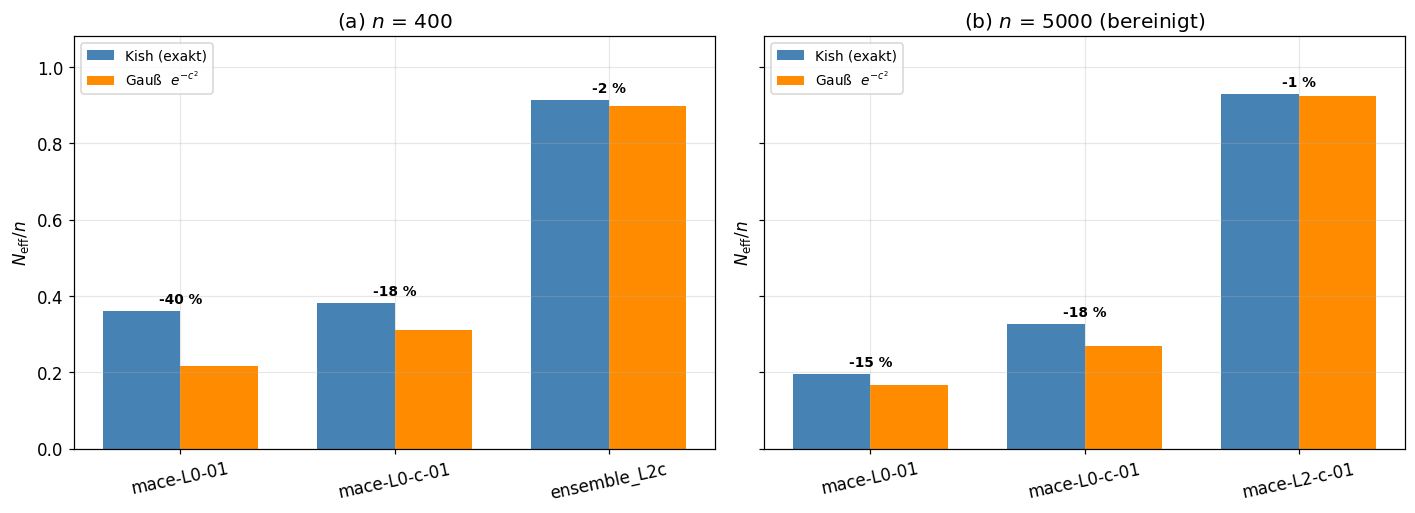

n = 400 (testbig):
Modell               c  gamma1 gamma1*c^3  (2c)^5/5!    Kish   Gauss   Fehler
mace-L0-01       1.238  +0.247      0.469      0.774   0.361   0.216   -40.1%
mace-L0-c-01     1.079  +0.207      0.260      0.391   0.382   0.312   -18.4%
ensemble_L2c     0.327  +0.501      0.017      0.001   0.912   0.899    -1.5%

n = 5000 (bereinigt):
Modell               c  gamma1 gamma1*c^3  (2c)^5/5!    Kish   Gauss   Fehler
mace-L0-01       1.340  +0.090      0.217      1.152   0.196   0.166   -15.3%
mace-L0-c-01     1.146  +0.127      0.192      0.527   0.327   0.269   -17.7%
mace-L2-c-01     0.283  +0.422      0.010      0.000   0.929   0.923    -0.7%


In [16]:
def kish_gauss_panel(ax, items, loader, title):
    ms = list(items); x = np.arange(len(ms)); wd = 0.36
    kish, gauss, rows = [], [], []
    for m in ms:
        e_dft, e_mace = loader(m); dE = e_dft - e_mace
        s = dE.std(ddof=1); u = dE - dE.mean()
        c = beta*s; g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4-3)
        k = effective_sample_size(reweighting_weights(e_dft, e_mace, beta))/dE.size
        kish.append(k); gauss.append(np.exp(-c**2))
        rows.append((m, c, g1, k, np.exp(-c**2), g1*c**3, (2*c)**5/120))
    ax.bar(x-wd/2, kish, wd, label="Kish (exakt)", color="steelblue")
    ax.bar(x+wd/2, gauss, wd, label="Gauß  $e^{-c^2}$", color="darkorange")
    for i in range(len(ms)):
        ax.text(i, max(kish[i], gauss[i])+0.02, f"{100*(gauss[i]/kish[i]-1):+.0f} %",
                ha="center", fontweight="bold", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(ms, rotation=12); ax.set_ylim(0, 1.08)
    ax.set_ylabel("$N_\\mathrm{eff}/n$"); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")
    return rows

def print_decomp(title, rows):
    print(title)
    print(f"{'Modell':<15}{'c':>7}{'gamma1':>8}{'gamma1*c^3':>11}{'(2c)^5/5!':>11}"
          f"{'Kish':>8}{'Gauss':>8}{'Fehler':>9}")
    for m, c, g1, k, ga, t3, R5 in rows:
        print(f"{m:<15}{c:>7.3f}{g1:>+8.3f}{t3:>11.3f}{R5:>11.3f}{k:>8.3f}{ga:>8.3f}"
              f"{100*(ga/k-1):>+8.1f}%")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
rows400  = kish_gauss_panel(a, SHOW_400,  lambda m: load_energies(CACHE / MODELS[m]),
                            "(a) $n$ = 400")
rows5000 = kish_gauss_panel(b, SHOW_5000, lambda m: load_full(m),
                            "(b) $n$ = 5000 (bereinigt)")
plt.tight_layout(); plt.show()

print_decomp("n = 400 (testbig):", rows400); print()
print_decomp("n = 5000 (bereinigt):", rows5000)

**Die Auflösung.** Der Gauß-Fehler hängt nicht davon ab, *wie* gaußisch $\Delta E$ ist,
sondern von $\gamma_1 c^3$ — **Form mal Skala-hoch-drei**. L0 hat sogar die *kleinere* Schiefe
($\gamma_1\approx0.2$ vs. $0.50$), aber sein $c^3$ ist ~50× größer ($1.24^3$ vs. $0.33^3$).
Der Schiefe-Beitrag $\gamma_1 c^3$ ist deshalb bei L0 rund 0.4–0.5, bei L2c nur 0.018 — Faktor
$\sim25$. Ein Normalitätstest misst die **Form**, nicht die $c$-Verstärkung, und geht deshalb
in die Irre. Die richtige Größe ist $\gamma_1 c^3$ (bzw. der Restterm $(2c)^5/5!$) — oder, wenn
man die Zahl braucht, **direkt Kish**.

### 4.4 Was das für L0 bedeutet

Der Gegensatz aus 4.1/4.3 wird jetzt zur Aussage — und beide Datensätze zeigen ihn:

- Bei kleinem $c$ (**L2**, $c\approx0.28$–$0.33$) ist $c^3$ winzig, die Formabweichung wird um
  Faktor $\sim30$–$45$ **gedämpft** — der Gauß-Term trägt, trotz nachgewiesener Nicht-Normalität
  ($\gamma_1 c^3\approx0.01$, Rest $\approx0$). Der Fehler bleibt unter 2 % (400) bzw. 1 % (5000).
- Bei großem $c$ (**L0**, $c\approx1.1$–$1.3$) ist $c^3\approx1.3$–$2.4$ **nicht** mehr gedämpft;
  die Form **dominiert**, und der effektive Entwicklungsparameter $2c\approx2.2$–$2.7$ liegt
  außerhalb des Konvergenzradius (§2.5) — die Reihe **divergiert** (Restterm $(2c)^5/5!\approx
  0.4$–$1.2$, Spalten oben). Der große Satz treibt $c$ sogar noch höher (1.24→1.34) — die
  Divergenz wird also **schärfer**, nicht milder.

**Konsequenz für den Workflow.** Für L0 ist der Gauß-/Kumulanten-*Prädiktor* wertlos — man nimmt
den exakten Kish-Wert (§2.1). Die **Entscheidung** bleibt davon unberührt: sie hängt an $c$
gegen $c_\text{max}$ (§2.6, §7), und $c=\beta\,\mathrm{std}(\Delta E)$ ist selbst dann robust,
wenn die Reihe längst nicht mehr trägt (§6). L0 ist also gerade der Fall, in dem die *Form* die
Prognose sprengt, die *Entscheidung* aber stabil bleibt — auf 400 wie auf 5000 Frames.

<a id="5"></a>
## 5. Die drei Diagnosegrößen: $c$, $\hat k$, $N_\text{eff}$

§2–§4 haben die Größen einzeln benutzt. Hier stellen wir sie **nebeneinander** und
beantworten die Leitfrage: *Warum reicht $c$ allein nicht — und wie wird aus der Kombination
ein verlässlicher Indikator?* Der Abschnitt schließt mit einem Beweis an den echten Daten.

### 5.1 Die drei Größen und ihre Rollen

| Größe | misst | Rolle | Charakter |
|---|---|---|---|
| $c=\beta\,\mathrm{std}(\Delta E)$ | Breite der $\Delta E$-Verteilung | **Skala / Entscheidung** | schnell, aber allein kein Prädiktor |
| $\hat k$ (PSIS-Tail) | Schwere des Gewichts-Tails | **Existenz-Gate** | ja/nein: existiert $N_\text{eff}$? |
| $N_\text{eff}$ (Kish) | $(\sum w)^2/\sum w^2$ | **exakte Wahrheit** | annahmefrei, nur auf vorhandenen Daten |

Die Werte für die realen Modelle als gemeinsamer Startpunkt:

In [17]:
import numpy as np
from uq_mace.reweighting import psis_khat

FOUR = ["ensemble_L2c", "mace-L2-c-01", "mace-L0-c-01", "mace-L0-01"]
print(f"{'Modell':<15}{'c':>8}{'khat':>9}{'N_eff/n (Kish)':>16}")
for m in FOUR:
    e_dft, e_mace = load_energies(CACHE / MODELS[m]); dE = e_dft - e_mace
    w = reweighting_weights(e_dft, e_mace, beta)
    print(f"{m:<15}{beta*dE.std(ddof=1):>8.3f}{psis_khat(w):>+9.3f}"
          f"{effective_sample_size(w)/dE.size:>16.3f}")

Modell                c     khat  N_eff/n (Kish)
ensemble_L2c      0.327   +0.068           0.912
mace-L2-c-01      0.335   -0.086           0.907
mace-L0-c-01      1.079   +0.416           0.382
mace-L0-01        1.238   +0.050           0.361


### 5.2 Warum $c$ allein kein Prädiktor ist

Behauptung: $c$ fixiert nur die **Skala**, nicht den Wert. Beweis durch Konstruktion — wir
bauen Verteilungen mit **identischem $c$** (alle mit $\mathrm{var}(z)=1$, also gleicher
$\mathrm{std}(\Delta E)$), aber verschiedener **Form**, und sehen, wie weit $N_\text{eff}/n$
dabei streut.

Das einfachste Beispiel ist eine **Zweipunkt-Verteilung**: ein häufiger Wert nahe 0 und ein
seltener Ausreißer (Wahrscheinlichkeit $p$), so justiert, dass Mittel 0 und Varianz 1 bleiben.
Ein seltener Ausreißer nach **links** ($\Delta E$ stark negativ) erzeugt ein dominierendes
Gewicht $\to N_\text{eff}\to$ klein; nach **rechts** bleiben die Gewichte fast gleich $\to
N_\text{eff}/n\to 1$ — bei **gleichem $c$**.

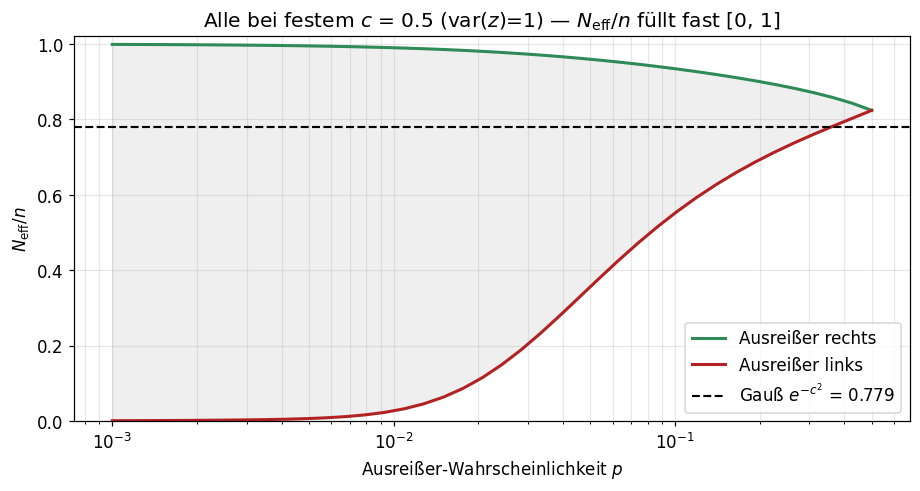

Bei c = 0.5:  N_eff/n von 0.0010 bis 0.9990  — Gauß-Wert 0.7788 liegt nur dazwischen.


In [18]:
c_fix = 0.5
def neff_twopoint(p, sign):
    b = np.sqrt((1-p)/p); a = -np.sqrt(p/(1-p))       # mean 0, var 1
    z = np.array([a, b]) * sign; pr = np.array([1-p, p])
    E1 = (pr*np.exp(-c_fix*z)).sum(); E2 = (pr*np.exp(-2*c_fix*z)).sum()
    return E1**2 / E2

ps = np.logspace(-3, np.log10(0.5), 40)
neff_hi = [neff_twopoint(p, +1) for p in ps]   # Ausreisser rechts -> hoch
neff_lo = [neff_twopoint(p, -1) for p in ps]   # Ausreisser links  -> tief

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.semilogx(ps, neff_hi, "-", color="seagreen", lw=2, label="Ausreißer rechts")
ax.semilogx(ps, neff_lo, "-", color="firebrick", lw=2, label="Ausreißer links")
ax.fill_between(ps, neff_lo, neff_hi, color="gray", alpha=0.12)
ax.axhline(np.exp(-c_fix**2), color="k", ls="--", lw=1.4,
           label=f"Gauß $e^{{-c^2}}$ = {np.exp(-c_fix**2):.3f}")
ax.set_xlabel("Ausreißer-Wahrscheinlichkeit $p$"); ax.set_ylabel("$N_\\mathrm{eff}/n$")
ax.set_ylim(0, 1.02); ax.set_title(f"Alle bei festem $c$ = {c_fix} (var$(z)$=1) — "
                                   f"$N_\\mathrm{{eff}}/n$ füllt fast [0, 1]")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

print(f"Bei c = {c_fix}:  N_eff/n von {min(neff_lo):.4f} bis {max(neff_hi):.4f}"
      f"  — Gauß-Wert {np.exp(-c_fix**2):.4f} liegt nur dazwischen.")

**Fazit.** Bei festem $c$ ist $N_\text{eff}/n$ **nicht bestimmt** — es hängt von der Form ab.
$c$ sagt nur, in welcher Größenordnung man sich bewegt. Distributionsfrei gilt allein:
$c\to 0 \Rightarrow N_\text{eff}/n\to 1$. Für eine echte Aussage braucht es die Form
($\gamma_1,\gamma_2$) **und** die Tail-Absicherung ($\hat k$).

### 5.3 Wie die Kombination zum Indikator wird

Der Indikator entsteht in **vier Schichten**, jede schließt eine Lücke, die die vorige offen
lässt:

**Schicht 1 — $c$: die Skala.** $c=\beta\,\mathrm{std}(\Delta E)$ misst die Breite, ist schnell
bestimmt (§6). Aber (5.2) bei festem $c$ ist $N_\text{eff}/n$ unbestimmt — $c$ allein gibt nur
die Größenordnung.

**Schicht 2 — Form ($\gamma_1,\gamma_2$): macht $c$ zur Prognose.** Die Kumulantenentwicklung
$N_\text{eff}/n = \exp(-c^2+\gamma_1 c^3-\tfrac{7}{12}\gamma_2 c^4)$ nutzt Skala **und** Form.
Damit ist die Lücke aus Schicht 1 geschlossen — kennt man beides, ist $N_\text{eff}/n$
festgelegt (wo die Reihe konvergiert, §2.5).

**Schicht 3 — $\hat k$: das Existenz-Gate.** Selbst mit $c$ und Form ist alles bedeutungslos,
falls $N_\text{eff}$ gar nicht existiert ($E[w^2]=\infty$). $\hat k<0.5$ garantiert die Existenz
— eine binäre Vorbedingung, unabhängig von $c$ und Form (Details §9).

**Schicht 4 — Kish: der exakte Anker.** Auf den vorhandenen Gewichten ist
$N_\text{eff}/n=(\sum w)^2/(n\sum w^2)$ exakt und annahmefrei — die Wahrheit, gegen die Schicht 2
geprüft wird, und der **Rückfallwert**, wenn die Reihe (großes $c$) versagt.

> **Der Indikator.** Die Entscheidung läuft über $c$ gegen $c_\text{max}$ (§7), abgesichert
> durch das $\hat k$-Gate und, wo nötig, den exakten Kish-Wert. Jede Größe schließt eine
> spezifische Lücke — Skala, Prognose, Existenz, Wahrheit —, keine ist durch die anderen
> ersetzbar. Das prüfen wir jetzt an den Daten.

### 5.4 Beweis an den echten Daten

Für jedes Modell stellen wir nebeneinander: den Gauß-Schätzer ($c$ **allein**), die
Kumulanten-Prognose ($c$ **+ Form**), und die exakte Kish-Wahrheit — plus das $\hat k$-Gate.
Panel **(a)** zeigt den Testsatz ($n$ = 400), Panel **(b)** den großen Satz
($n$ = 5000, 4 DFT-Artefakte entfernt) im selben Stil.

n = 400  (testbig):
Modell              c   khat   Gate      Reihe |   Gauß(c)  Kumul.(c+Form)    Kish
--------------------------------------------------------------------------------------------
ensemble_L2c    0.327 +0.068     OK konvergent |     0.899           0.912   0.912
mace-L2-c-01    0.335 -0.086     OK konvergent |     0.894           0.907   0.907
mace-L0-c-01    1.079 +0.416     OK  divergent |     0.312         (0.362)   0.382
mace-L0-01      1.238 +0.050     OK  divergent |     0.216         (0.304)   0.361

n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):
Modell              c   khat   Gate      Reihe |   Gauß(c)  Kumul.(c+Form)    Kish
--------------------------------------------------------------------------------------------
mace-L0-01      1.340 +0.314     OK  divergent |     0.166         (0.228)   0.196
mace-L0-c-01    1.146 +0.223     OK  divergent |     0.269         (0.347)   0.327
mace-L2-c-01    0.283 +0.024     OK konvergent |     0.923           0.929   0

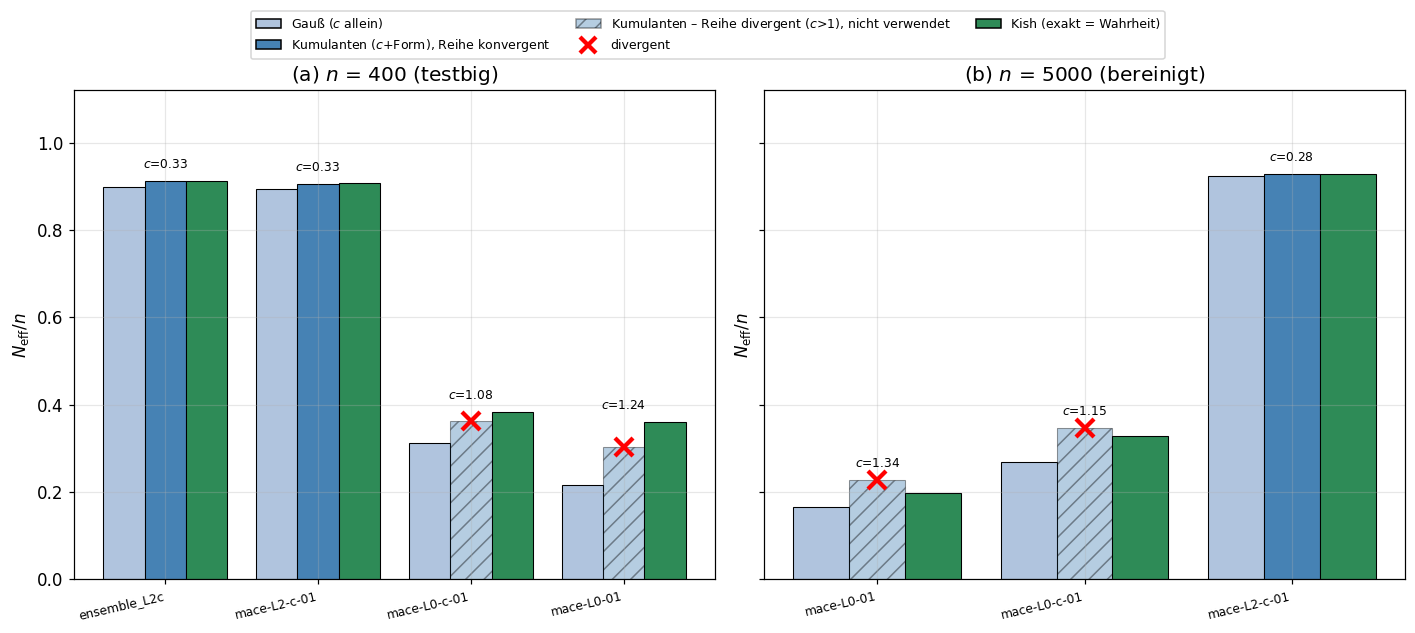

In [19]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def proof_stats(e_dft, e_mace):
    dE = e_dft - e_mace
    s = dE.std(ddof=1); u = dE - dE.mean()
    c = beta*s; g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4-3)
    w = reweighting_weights(e_dft, e_mace, beta)
    kish = effective_sample_size(w)/dE.size; kh = psis_khat(w)
    return c, kh, np.exp(-c**2), np.exp(-c**2 + g1*c**3 - 7/12*g2*c**4), kish

def proof_table(title, items):
    print(title)
    print(f"{'Modell':<14}{'c':>7}{'khat':>7}{'Gate':>7}{'Reihe':>11} | "
          f"{'Gauß(c)':>9}{'Kumul.(c+Form)':>16}{'Kish':>8}")
    print("-"*92)
    for m, (e_dft, e_mace) in items:
        c, kh, gauss, kumul, kish = proof_stats(e_dft, e_mace)
        gate = "OK" if kh < 0.5 else "FAIL"
        div  = "divergent" if (2*c)**5/120 >= 0.05 else "konvergent"
        # bei Divergenz ist die Kumulanten-Zahl formal ungueltig -> als (…) markiert
        kstr = f"({kumul:.3f})" if div == "divergent" else f"{kumul:.3f}"
        print(f"{m:<14}{c:>7.3f}{kh:>+7.3f}{gate:>7}{div:>11} | "
              f"{gauss:>9.3f}{kstr:>16}{kish:>8.3f}")

proof_table("n = 400  (testbig):",
            [(m, load_energies(CACHE / MODELS[m])) for m in FOUR])
print()
proof_table("n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):",
            [(m, load_full(m)) for m in MODELS_FULL])
print("\n(...) = Reihe divergent (c>1), Wert formal ungueltig -> es gilt der exakte Kish-Wert.")

# Drei Balken je Modell: Gauss-Praediktor, Kumulanten-Praediktor, Kish (Wahrheit).
# Divergente Reihe (c>1) -> Kumulanten-Balken schraffiert + rot durchgestrichen (nicht verwendet).
def proof_bars(ax, items, title):
    ms = list(items); x = np.arange(len(ms)); w = 0.27
    for i, m in enumerate(ms):
        c, kh, gauss, kumul, kish = proof_stats(*items[m])
        div = (2*c)**5/120 >= 0.05
        ax.bar(x[i]-w, gauss, w, color="lightsteelblue", edgecolor="k", lw=0.7)
        ax.bar(x[i],   kumul, w, color="steelblue", edgecolor="k", lw=0.7,
               hatch="//" if div else "", alpha=0.4 if div else 1.0)
        ax.bar(x[i]+w, kish,  w, color="seagreen", edgecolor="k", lw=0.7)
        if div:
            ax.plot(x[i], kumul, "x", color="red", ms=12, mew=2.8, zorder=6)
        ax.text(x[i], max(gauss, kumul, kish)+0.03, f"$c$={c:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(ms, rotation=13, ha="right", fontsize=8)
    ax.set_ylabel("$N_\\mathrm{eff}/n$"); ax.set_ylim(0, 1.12); ax.set_title(title)
    ax.grid(alpha=0.3, axis="y")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
proof_bars(a, {m: load_energies(CACHE / MODELS[m]) for m in FOUR}, "(a) $n$ = 400 (testbig)")
proof_bars(b, {m: load_full(m) for m in MODELS_FULL},              "(b) $n$ = 5000 (bereinigt)")
handles = [Patch(fc="lightsteelblue", ec="k", label="Gauß ($c$ allein)"),
           Patch(fc="steelblue", ec="k", label="Kumulanten ($c$+Form), Reihe konvergent"),
           Patch(fc="steelblue", ec="k", hatch="//", alpha=0.4,
                 label="Kumulanten – Reihe divergent ($c$>1), nicht verwendet"),
           Line2D([], [], color="red", marker="x", ls="", ms=11, mew=2.8, label="divergent"),
           Patch(fc="seagreen", ec="k", label="Kish (exakt = Wahrheit)")]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=8.2, bbox_to_anchor=(0.5, 1.07))
plt.tight_layout(); plt.show()

**Was der Beweis zeigt** (Panel (a) $n$=400, Panel (b) $n$=5000; je drei Balken pro Modell):

- **$c$ allein (Gauß, hellblau)** trifft für die guten Modelle fast die Kish-Wahrheit, für L0 aber weit daneben (bis $-40\,\%$ bei $n$=400, $-18\,\%$ bei $n$=5000) — bestätigt 5.2: die Skala genügt nicht.
- **$c$ + Form (Kumulanten, dunkelblau)** ist nur dort gezeichnet, wo die **Reihe konvergiert** ($c<1$, Restglied $(2c)^5/5!<0.05$): für **L2c/L2-c-01** trifft sie die Wahrheit exakt ($<0.1\,\%$ in beiden Sätzen). Für **L0** ist $c\approx1.1$–1.34, die Reihe **divergiert** (§2.5) — der Balken ist deshalb **schraffiert und rot durchgestrichen**: er zeigt nur, *was* die divergente Reihe ausspuckt, wird aber **nicht verwendet**. Dort gilt allein der exakte Kish-Wert (grün, Schicht 4).
- **$\hat k$-Gate** ist bei allen bestanden ($<0.5$), $N_\text{eff}$ existiert also überall. L0-c-01 liegt bei $n$=400 mit $0.42$ nahe an der Grenze; auf dem größeren Satz entspannt sich das auf $0.22$ (mehr Frames, stabilerer Schwanz-Schätzer, §9).

Die Rollen bleiben sauber getrennt: bei kleinem $c$ liefert die Reihe die genaue Prognose (hell- und dunkelblau decken den grünen Balken), bei großem $c$ ist sie ungültig und man liest direkt den grünen Kish-Balken. Das **reproduziert sich von 400 auf 5000 Frames** — und **keine der Größen allein leistet es**.

<a id="6"></a>
## 6. Konvergenz der Momente

§5 hat gezeigt: ohne die Form ($\gamma_1,\gamma_2$) ist keine Aussage möglich — sie sind
**essenziell**. Zugleich konvergieren sie **langsam und verzerrt**. Dieser Abschnitt löst die
Spannung auf: Wie schnell konvergieren $c,\gamma_1,\gamma_2$, woher kommen ihre Standardfehler,
und warum ist die langsame Konvergenz für die Entscheidung trotzdem unkritisch.

### 6.1 Woher die Standardfehler kommen

Der Standardfehler von $c=\beta\sigma$ (mit $\sigma=\mathrm{std}(\Delta E)$, §2.2) folgt aus
einer einzigen Beobachtung: **die Stichprobenvarianz ist selbst ein Mittelwert.** Damit ist der
Rest gewöhnliche Fehlerfortpflanzung.

Schreibe den Schätzer $\widehat{\sigma^2}$ als

$$\widehat{\sigma^2} \approx \frac{1}{k}\sum_{i=1}^{k}\underbrace{(\Delta E_i-\mu)^2}_{\equiv\,Y_i},$$

also den Mittelwert von $k$ Zahlen $Y_i=(\Delta E_i-\mu)^2$ mit $E[Y]=\sigma^2$. Für den
Mittelwert von irgendetwas ist die Unsicherheit bekannt:
$\mathrm{Var}(\overline Y)=\mathrm{Var}(Y)/k$ — das ist der Ursprung des $1/k$, dasselbe
Averaging-Argument wie beim Standardfehler des Mittelwerts.

**Schritt 1 — die Varianz von $Y$.** Mit $Y=(\Delta E-\mu)^2$ ist

$$\mathrm{Var}(Y)=E[Y^2]-E[Y]^2=E[(\Delta E-\mu)^4]-\big(E[(\Delta E-\mu)^2]\big)^2=\mu_4-\sigma^4,$$

mit $\mu_4$ dem vierten zentralen Moment. Also

$$\mathrm{Var}(\widehat{\sigma^2})=\frac{\mu_4-\sigma^4}{k}.$$

Anschaulich: die Varianz ist aus *quadrierten* Abweichungen gebaut, ihre Schwankung hängt daher
an *vierten* Potenzen — am vierten Moment. Ausreißer (dicke Flanken) bewegen sie stark.

**Schritt 2 — die Form einsetzen.** Die Exzess-Kurtosis ist $\gamma_2=\mu_4/\sigma^4-3$ (§2.3),
also $\mu_4=(\gamma_2+3)\sigma^4$ und damit $\mu_4-\sigma^4=(\gamma_2+2)\sigma^4$. In
**relativer** Form (teilen durch $\sigma^2$, quadriert also $\sigma^4$):

$$\frac{\mathrm{SE}(\widehat{\sigma^2})}{\sigma^2}=\frac{\sqrt{(\gamma_2+2)\sigma^4/k}}{\sigma^2}=\sqrt{\frac{\gamma_2+2}{k}}.$$

Das $\sigma^4$ kürzt sich weg — die *relative* Präzision der Varianz hängt nur an der Form
($\gamma_2$) und der Stichprobengröße ($k$), nicht an der Skala.

**Schritt 3 — von der Varianz zur Standardabweichung (die Wurzel).** Gebraucht wird
$\sigma=\sqrt{\sigma^2}$. Die Delta-Methode gibt für eine Funktion $g$ den Zusammenhang
$\mathrm{SE}(g(X))\approx|g'|\,\mathrm{SE}(X)$; mit $g(X)=\sqrt X$ und $g'=\tfrac{1}{2\sqrt X}$
wird

$$\frac{\mathrm{SE}(\sqrt X)}{\sqrt X}=\frac{\mathrm{SE}(X)/(2\sqrt X)}{\sqrt X}=\frac12\,\frac{\mathrm{SE}(X)}{X}.$$

Die Wurzel **halbiert den relativen Fehler** (weil $\mathrm{d}\ln\sqrt X=\tfrac12\,\mathrm{d}\ln X$):
ist die Varianz auf ±10 % bekannt, dann $\sigma$ auf ±5 %. Also

$$\frac{\mathrm{SE}(\hat\sigma)}{\sigma}=\frac12\sqrt{\frac{\gamma_2+2}{k}}=\sqrt{\frac{\gamma_2+2}{4k}}.$$

**Schritt 4 — von $\sigma$ zu $c$.** $c=\beta\sigma$ mit der Konstanten $\beta$; eine Konstante
ändert den *relativen* Fehler nicht und kürzt sich in
$\mathrm{SE}(c)/c=\mathrm{SE}(\hat\sigma)/\sigma$ heraus:

$$\boxed{\;\frac{\mathrm{SE}(c)}{c}=\sqrt{\frac{\gamma_2+2}{4k}}\;}$$

Der Grenzfall Gauß ($\gamma_2=0$) gibt $\mathrm{SE}(c)/c=1/\sqrt{2k}$ — die vertraute
$1/\sqrt{k}$-Rate; dicke Flanken ($\gamma_2>0$) vergrößern sie. Invertiert,
$k=(\gamma_2+2)/(4\varepsilon^2)$, ist es genau die „wie viele DFT-Punkte für $\varepsilon$ %
Präzision auf $c$"-Formel aus §6.3. Die einzigen Näherungen sind „die Varianz ist ein
Mittelwert" (exakt bis auf den bei großem $k$ vernachlässigbaren $(k-1)/k$-Bias) und die
Linearisierung der Wurzel — beides **verteilungsallgemein**, nirgends steckt Normalität drin,
nur ein endliches viertes Moment.

**$\gamma_1,\gamma_2$ — Unsicherheit ausschließlich per Bootstrap.** $\gamma_1$ ist die Schiefe,
$\gamma_2$ die Exzess-Kurtosis von $\Delta E$ (§2.3, §5) — die beiden Formkorrekturen der
Kumulantenentwicklung. Geschlossene Standardfehler gibt es für sie nur unter der Nullhypothese
„$\Delta E$ normalverteilt". $\Delta E$ ist aber nachweislich *nicht* normal (§4); dann hängt die
wahre Varianz von $\gamma_1,\gamma_2$ von noch höheren Momenten ab und ist **größer** als die
Normaltheorie — eine analytische Formel würde die Unsicherheit systematisch unterschätzen.
Deshalb schätzen wir $\mathrm{SE}(\gamma_1)$ und $\mathrm{SE}(\gamma_2)$ **ausschließlich per
Bootstrap** (§6.2), ohne analytische Näherung.

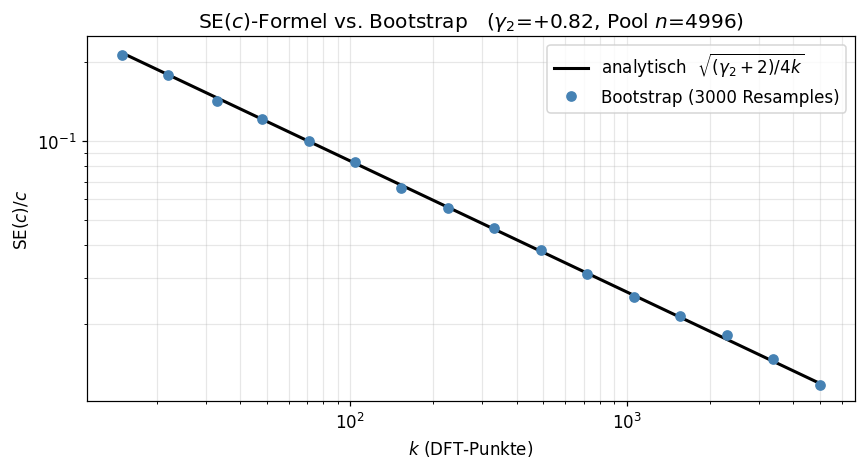

max. Abweichung Bootstrap/analytisch: 3.9 %   (über k = 15…4996)


In [20]:
# Verifikation der SE(c)-Formel gegen den Bootstrap (gut-artiger Pool L2-c-01, n=5000 bereinigt)
import numpy as np
import matplotlib.pyplot as plt

ed_v, em_v = load_full("mace-L2-c-01")                 # bereinigt (ohne die 4 DFT-Artefakte)
dE_v = ed_v - em_v
g2_v = float(((dE_v - dE_v.mean())**4).mean() / dE_v.std(ddof=1)**4 - 3)
c_v  = beta * dE_v.std(ddof=1)

rng = np.random.default_rng(0)
ks_v = np.unique(np.round(np.geomspace(15, dE_v.size, 16)).astype(int))
se_boot, se_ana = [], []
for k in ks_v:
    cb = beta * np.array([dE_v[rng.integers(0, dE_v.size, k)].std(ddof=1) for _ in range(3000)])
    se_boot.append(cb.std(ddof=1) / c_v)               # Bootstrap-SE, relativ
    se_ana.append(np.sqrt((g2_v + 2) / (4 * k)))       # Formel aus 6.1
se_boot, se_ana = np.array(se_boot), np.array(se_ana)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.loglog(ks_v, se_ana,  color="k", lw=2, label=r"analytisch  $\sqrt{(\gamma_2+2)/4k}$")
ax.loglog(ks_v, se_boot, "o", color="steelblue", ms=6, label="Bootstrap (3000 Resamples)")
ax.set_xlabel("$k$ (DFT-Punkte)"); ax.set_ylabel(r"$\mathrm{SE}(c)/c$")
ax.set_title(f"SE($c$)-Formel vs. Bootstrap   ($\\gamma_2$={g2_v:+.2f}, Pool $n$={dE_v.size})")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

print(f"max. Abweichung Bootstrap/analytisch: {np.abs(se_boot/se_ana - 1).max()*100:.1f} %"
      f"   (über k = {ks_v.min()}…{ks_v.max()})")

### 6.2 Bootstrap-Konvergenz und Bias

Wir ziehen Bootstrap-Stichproben der Größe $k$ und verfolgen Median und 5–95 %-Band von $c,\gamma_1,\gamma_2$ — **aus den 400 Testframes** (blau, $k$ bis 400) und **aus dem großen Satz** (rot, $k$ bis 5000). Der größere Pool lässt $k$ weiter laufen und zeigt, wie die Bänder über $k=400$ hinaus schrumpfen.

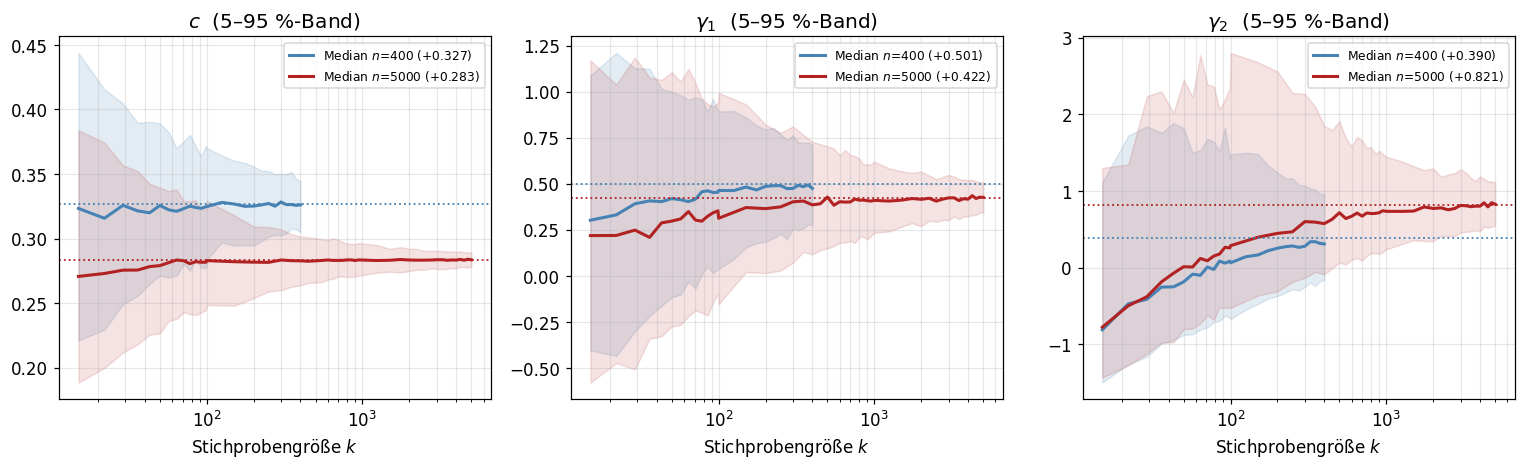

Standardfehler  (Bootstrap  vs.  Normaltheorie-Formel):
  n=400,  k=400 :  c=0.0127 (Formel 0.0126) | g1=0.1355 (sqrt(6/k) 0.1225) | g2=0.3687 (sqrt(24/k) 0.2449)
  n=5000, k=400 :  c=0.0121 (Formel 0.0119) | g1=0.1820 (sqrt(6/k) 0.1225) | g2=0.6087 (sqrt(24/k) 0.2449)
  n=5000, k=5000:  c=0.0034 (Formel 0.0034) | g1=0.0508 (sqrt(6/k) 0.0346) | g2=0.1738 (sqrt(24/k) 0.0693)   <- volle erreichbare Praezision

(g2-Formel unterschaetzt durchweg -> nicht-normale Verteilung, Warnung aus 6.1)


In [21]:
import numpy as np
import matplotlib.pyplot as plt

def moments(d):
    s = d.std(ddof=1); u = d - d.mean()
    return beta*s, float((u**3).mean()/s**3), float((u**4).mean()/s**4-3)

def boot_band(dE, ks, nboot=400, seed=0):
    rng = np.random.default_rng(seed); n = dE.size
    out = {q: {j: [] for j in range(3)} for q in ("med","lo","hi")}
    for k in ks:
        M = np.empty((nboot, 3))
        for b in range(nboot):
            M[b] = moments(dE[rng.integers(0, n, k)])
        for j in range(3):
            out["med"][j].append(np.median(M[:, j]))
            out["lo"][j].append(np.percentile(M[:, j], 5))
            out["hi"][j].append(np.percentile(M[:, j], 95))
    return {q: {j: np.array(v) for j, v in out[q].items()} for q in out}

dE4 = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))          # 400 Frames
dEf = np.subtract(*load_full("mace-L2-c-01"))                             # 5000, bereinigt
t4  = moments(dE4); tf = moments(dEf)
c0, g10, g20 = t4          # 400er-Referenz (ensemble_L2c) fuer 6.3

ks4 = np.unique(np.r_[np.arange(15,100,7), np.arange(100,401,25)])
ksf = np.unique(np.r_[np.arange(15,100,7), np.arange(100,1000,50), np.arange(1000,5001,250)])
b4  = boot_band(dE4, ks4); bf = boot_band(dEf, ksf)

fig, axs = plt.subplots(1, 3, figsize=(14, 4.4))
labs = ["$c$", "$\\gamma_1$", "$\\gamma_2$"]
for j, (ax, lab) in enumerate(zip(axs, labs)):
    ax.semilogx(ks4, b4["med"][j], color="steelblue", lw=2, label=f"Median $n$=400 ({t4[j]:+.3f})")
    ax.fill_between(ks4, b4["lo"][j], b4["hi"][j], color="steelblue", alpha=0.15)
    ax.semilogx(ksf, bf["med"][j], color="firebrick", lw=2, label=f"Median $n$=5000 ({tf[j]:+.3f})")
    ax.fill_between(ksf, bf["lo"][j], bf["hi"][j], color="firebrick", alpha=0.13)
    ax.axhline(t4[j], color="steelblue", ls=":", lw=1.2)
    ax.axhline(tf[j], color="firebrick", ls=":", lw=1.2)
    ax.set_xlabel("Stichprobengröße $k$"); ax.set_title(f"{lab}  (5–95 %-Band)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

# Bootstrap-SE vs. Normaltheorie-Formel
def se_line(dE, k, seed=1):
    rng = np.random.default_rng(seed)
    B = np.array([moments(dE[rng.integers(0, dE.size, k)]) for _ in range(1000)])
    se = B.std(axis=0); c0, g10, g20 = moments(dE)
    return (f"  c={se[0]:.4f} (Formel {c0*np.sqrt((g20+2)/(4*k)):.4f}) | "
            f"g1={se[1]:.4f} (sqrt(6/k) {np.sqrt(6/k):.4f}) | "
            f"g2={se[2]:.4f} (sqrt(24/k) {np.sqrt(24/k):.4f})")
print("Standardfehler  (Bootstrap  vs.  Normaltheorie-Formel):")
print(f"  n=400,  k=400 :{se_line(dE4, 400)}")
print(f"  n=5000, k=400 :{se_line(dEf, 400)}")
print(f"  n=5000, k=5000:{se_line(dEf, 5000)}   <- volle erreichbare Praezision")
print("\n(g2-Formel unterschaetzt durchweg -> nicht-normale Verteilung, Warnung aus 6.1)")

**Drei Beobachtungen:**

- **Konvergenzgeschwindigkeit.** $c$ ist schon bei kleinem $k$ **unverzerrt** (der Median trifft den wahren Wert), seine **Präzision** verbessert sich aber weiter. Die SE-Formel aus §6.1 ist $\mathrm{SE}(c)/c=\sqrt{(\gamma_2+2)/4k}$; nach $k$ aufgelöst (mit $\varepsilon\equiv\mathrm{SE}(c)/c$) wird daraus $k=(\gamma_2+2)/(4\varepsilon^2)$. Damit entspricht $\varepsilon=20\,\%$ gerade $k\approx15$, $\varepsilon=10\,\%$ etwa $k\approx60$, $\varepsilon=5\,\%$ erst $k\approx240$. $\gamma_1$ ($\mathrm{SE}\approx\sqrt{6/k}$) und $\gamma_2$ ($\mathrm{SE}\approx\sqrt{24/k}$) folgen derselben $\sqrt{1/k}$-Rate mit größeren Vorfaktoren.
- **Was der große Satz bringt.** Die roten Bänder laufen bis $k=5000$ und schrumpfen weit unter das, was 400 Frames erlauben — bei $k=5000$ ist $c$ auf rund $\pm2\,\%$ bestimmt, $\gamma_2$ auf etwa $\pm0.2$. Die $k$-Schwellen selbst (15/60/240 für 20/10/5 %) sind aber **skalenfrei**: sie hängen nur an $\gamma_2$, nicht am Pool. Der große Satz senkt also nicht die Schwelle, sondern erlaubt, sie zu **überschreiten**.
- **Bias bei kleinem $k$.** $\gamma_1,\gamma_2$ sind nach unten verzerrt (bei $k=15$ deutlich unter dem Endwert). Das ist die **sichere Richtung**: unterschätzte Schiefe → schwächere Formkorrektur → Schranke näher an Gauß → konservativer, nie fälschlich PASS (§2.6).

Der Bootstrap-SE für $\gamma_2$ liegt in **beiden** Pools über der Normaltheorie-Formel — die Warnung aus 6.1 bestätigt sich unabhängig von $n$.

### 6.3 Fehlerfortpflanzung — warum die langsame Konvergenz unkritisch ist

$\gamma_1,\gamma_2$ gehen nicht direkt in $N_\text{eff}$ ein, sondern gedämpft über $c^3$ bzw.
$c^4$. Ihre Unsicherheit pflanzt sich also als $\mathrm{SE}(\gamma_1)\,c^3$ und
$\mathrm{SE}(\gamma_2)\,c^4$ fort — bei kleinem $c$ winzig.

Beitrag der Terme zu log(N_eff/n) und ihre Unsicherheit (SE bei k=400):

     c      -c^2           +g1 c^3    -7/12 g2 c^4
  0.33    0.1069    0.0175 ± 0.0043        0.0026   (0.4 % auf N_eff)
  0.50    0.2500    0.0626 ± 0.0153        0.0142   (1.5 % auf N_eff)
  0.70    0.4900    0.1718 ± 0.0420        0.0546   (4 % auf N_eff)
  1.00    1.0000    0.5008 ± 0.1225        0.2275   (12 % auf N_eff)


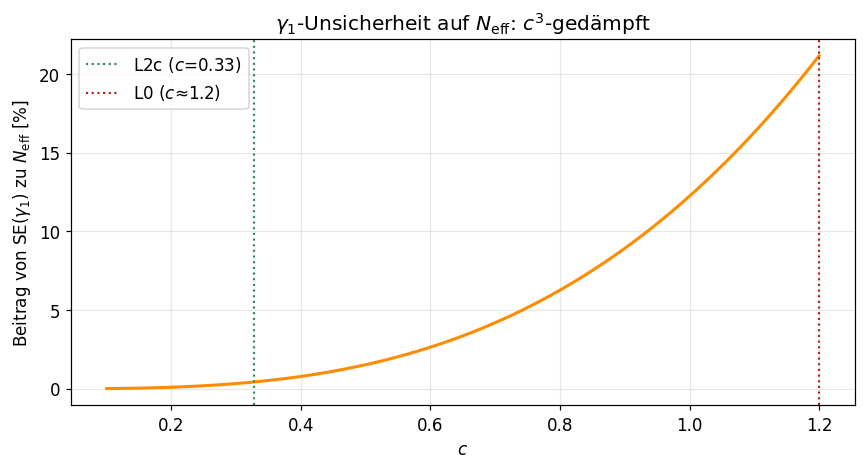

In [22]:
SEc = c0*np.sqrt((g20+2)/1600); SEg1 = np.sqrt(6/400); SEg2 = np.sqrt(24/400)
print(f"Beitrag der Terme zu log(N_eff/n) und ihre Unsicherheit (SE bei k=400):\n")
print(f"{'c':>6}{'-c^2':>10}{'+g1 c^3':>18}{'-7/12 g2 c^4':>16}")
for c in (0.327, 0.5, 0.7, 1.0):
    t2=c**2; t3=g10*c**3; t4=7/12*g20*c**4
    se3=c**3*SEg1                    # dominanter Beitrag der g1-Unsicherheit
    print(f"{c:>6.2f}{t2:>10.4f}{t3:>10.4f} ± {se3:<5.4f}{t4:>14.4f}"
          f"   ({100*se3:.1f} % auf N_eff)" if c<0.6 else
          f"{c:>6.2f}{t2:>10.4f}{t3:>10.4f} ± {se3:<5.4f}{t4:>14.4f}   ({100*se3:.0f} % auf N_eff)")

# g1-Unsicherheit auf N_eff als Funktion von c
cc = np.linspace(0.1, 1.2, 100)
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(cc, 100*cc**3*SEg1, color="darkorange", lw=2)
ax.axvline(0.327, color="seagreen", ls=":", lw=1.4, label="L2c ($c$=0.33)")
ax.axvline(1.2, color="firebrick", ls=":", lw=1.4, label="L0 ($c$≈1.2)")
ax.set_xlabel("$c$"); ax.set_ylabel("Beitrag von SE($\\gamma_1$) zu $N_\\mathrm{eff}$ [%]")
ax.set_title("$\\gamma_1$-Unsicherheit auf $N_\\mathrm{eff}$: $c^3$-gedämpft")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Die Auflösung.** Bei L2c ($c=0.33$) trägt die $\gamma_1$-Unsicherheit nur **0.4 %** zu
$N_\text{eff}$ bei — obwohl $\gamma_1$ selbst auf ~27 % genau ist. Der $c^3$-Faktor (0.036)
dämpft alles weg. Erst bei $c\gtrsim0.7$ wird der Beitrag spürbar (>4 %), und bei $c\approx1$
(L0) sind es 12 % — aber dort divergiert die Reihe ohnehin (§2.5, §4.4), und man nimmt den
exakten Kish-Wert.

$\gamma_1,\gamma_2$ sind also **essenziell für den Wert** (§5), ihre langsame und verzerrte
Konvergenz ist aber für die **Entscheidung folgenlos**: gedämpft bei kleinem $c$, und der Bias
zeigt in die sichere Richtung.

### 6.4 Konsequenz

- **$c$** ist die tragende Größe: unverzerrt ab $k\approx15$ (dort $\pm20\,\%$), auf $\pm10\,\%$
  ab $k\approx60$, mit SE $\sqrt{(\gamma_2+2)/4k}$ — und die einzige, die in die Schranke
  $c\le c_\text{max}$ eingeht. Liegt $c$ weit von $c_\text{max}$ (L0: $1.2$ vs. $0.47$),
  genügen die $\pm20\,\%$ bei $k\approx15$ für ein sicheres Urteil; nahe der Schwelle braucht
  es mehr Punkte.
- **$\gamma_1,\gamma_2$** rechnet man mit, weil ohne sie keine Prognose möglich ist (§5); ihre
  Ungenauigkeit gefährdet weder Prognose (bei kleinem $c$ gedämpft) noch Entscheidung (Bias in
  die sichere Richtung).

Damit steht das Fundament für §7: die Entscheidung ruht auf dem schnell konvergierenden $c$, die
Formkorrekturen verschieben nur die Schranke — kontrolliert und konservativ.

<a id="7"></a>
## 7. Die Entscheidungsschranke (Gauß vs. schiefe-korrigiert)

*$c_\text{max}=\sqrt{-\ln R}$ vs. Quartik; Falsch-FAIL-Zone; warum $\gamma_1$ mitgerechnet wird.*

> _(folgt)_

<a id="8"></a>
## 8. Der sequenzielle Workflow

*Iteratives Sammeln, z-Band-Entscheidungsregel, wie frueh das Urteil steht, DFT-Ersparnis bei L0.*

> _(folgt)_

<a id="9"></a>
## 9. Existenz von $N_\text{eff}$ und die PASS/FAIL-Asymmetrie

*khat als Existenz-Gate nur auf dem PASS-Zweig; Monotonie von Neff in der Tail-Schwere; schnellere Diagnosen (CV-Drift, Max-Einfluss).*

> _(folgt)_

<a id="10"></a>
## 10. Verifikation: analytisch bekannte Wahrheit

*Gamma-Modell (unter exp. Tilten geschlossen): Schaetzer trifft die analytische Wahrheit; Gueltigkeitsgrenze.*

> _(folgt)_

<a id="11"></a>
## 11. Grenzen: Abdeckung (A2) und Nicht-iid

*Loch-in-der-Flaeche (Screening blind), Sample- vs. Verteilungs-Beschraenktheit, iid-Voraussetzung, Ueberwachung an der Trajektorie.*

> _(folgt)_

<a id="12"></a>
## 12. Zusammenfassung

*Was belegt ist, was Annahme bleibt, offene Fragen an Tobi.*

> _(folgt)_